# ForceGNN Usage Example

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.


In [412]:
# Import everything from the module
import sys
sys.path.append('..')

import importlib
# import AmandaDataGNN.GNN_inference_UD_Masking
# importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking)
# from AmandaDataGNN.GNN_inference_UD_Masking import *
import AmandaDataGNN.GNN_inference_UD_Masking
importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking)
from AmandaDataGNN.GNN_inference_UD_Masking import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


## Step 1: Load and Prepare Data


In [484]:
# Load data
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Experimental"
#datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/IlyaMethod/AmandaIlya/CreatingUniformDataframe/"
#datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/AmandaData/DataFrames/"
dataname = "treatment_control_edges_OG_All.csv"
#dataname  ="treatment_control_edges_Att_offset49_All.csv"
dataname  ="treatment_control_edges_Att_offset49_All_BadTracksTrunc.csv"
#dataname  ="df_cells_B4_400ELA_2_dox1_offset_53_treatment_N1000_filt2.csv"
#dataname  ='df_cells_D3_400nmELA_ctrl_w2_15min_offset_49_treatment_N1000_filt2.csv'
#dataname  ='df_cells_D3_400nmELA_ctrl_w2_15min_offset_49_treatment_N2000_filt.csv'

#dataname = "df_cells_B4_400ELA_2_dox1_offset_53_treatment_N1000_filt2.csv"
#dataname = "df_cells_D1toD3_ctrl_w1_offset_1_control_N1000_filt2.csv"

data = load_data(datadir, dataname)
print(data.head())
print(np.min(data['x']),np.max(data['x']))
print(np.min(data['y']),np.max(data['y']))
#data = data.sort_values(by = 'frame')



# re-index the frame to be 0,1,2,3...
print(data.frame.unique())
IndexFrame = data.frame.unique()
IndexFrame.sort()
data['frame'] = data['frame'].map(dict(zip(IndexFrame, range(len(IndexFrame)))))
print(data.frame.unique())
data = data.sort_values(by='frame')
data = data.sort_values(by='particle').reset_index(drop=True)
print(data.frame.unique())
CellInd = data.index[data['particle'].diff().ne(0)].tolist()
# Add the last index to the list to cover the final group
CellInd.append(len(data) - 1) #filtered_file_ids = ['circle1_offset_23', 'circle2_offset_23', 'circle3_offset_23', 'circle4_offset_23']
print(len(CellInd))
#Data loaded: (20945, 4)
#Data loaded: (25692, 4)

Data loaded: (25692, 4)
Columns: ['frame', 'particle', 'x', 'y']
Number of frames: 24
   frame  particle           x           y
0      1         1  185.848727  466.913362
1      2         1  184.782955  469.593083
2      3         1  184.352541  468.848326
3      4         1  184.565606  465.113686
4      5         1  184.060934  464.589472
0.2534154624030649 648.1660612712088
1.4294171360886248 647.8333377973752
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[ 0  5 21 18 15 14  2 20  8  9  7  1  3 10 16 13 11 12  6 19  4 17 23 22]
1315


Number of cells =  1314


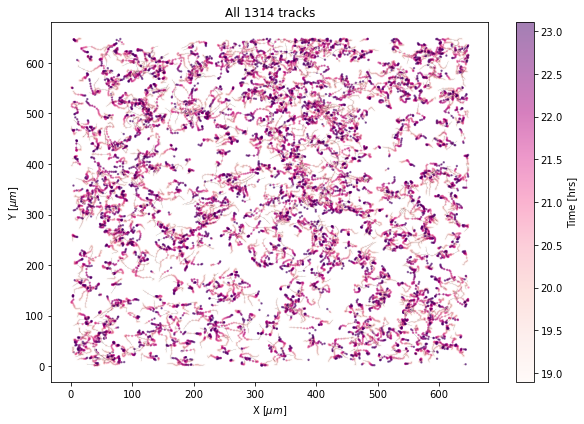

In [485]:
# first plot all the cells
fig,ax = plt.subplots(1,figsize=(8.5,6))
print("Number of cells = ",len(CellInd)-1)
count=0
CellNumCh =len(CellInd)
counter2 = 0
for cell in range(CellNumCh-1): #len(CellInd)-1
    ci = cell #*12
    #ci = np.random.randint(0, len(CellInd)-1)
    Tstart = CellInd[ci]+1
    Tend = CellInd[ci+1]
    #print("Tstart, Tend:", Tstart, Tend)
    MaxTime = data.frame.max()
    #print("Max time:", MaxTime)
    trajectory_data = data.iloc[Tstart:Tend]
    #print("Trajectory data shape:", trajectory_data)
    trajectory_data = trajectory_data.sort_values(by='frame')
    if len(trajectory_data.frame.unique()) != len(trajectory_data.frame):
        #print('Skipping cell',cell)
        counter2 +=1
        continue
    count+=1
    line = ax.plot(
        trajectory_data.x, 
        trajectory_data.y, 
        color='black',  # Set the color of the line
        linewidth=0.1,  # Set the line width
        linestyle='-',  # Set the line style
    )
    sc = ax.scatter(
        trajectory_data.x, 
        trajectory_data.y, 
        #c = clrs[cell],
        label = cell,
        c=trajectory_data.frame,  # Use EDGE_TIME for color mapping
        cmap='RdPu',  # Set the colormap
        s=2,  # Set marker size
        alpha = 0.5,
    )

plt.colorbar(sc, ax=ax, label='Time [hrs]')
ax.set_xlabel(r'X [$\mu m$]')  
ax.set_ylabel(r'Y [$\mu m$]') 
#ax.set_xlim([0,1300])
#ax.set_ylim([0,1300])
ax.set_title('All '+str(len(CellInd)-1)+' tracks')
fig.tight_layout()  


In [328]:
print(900-data['x'].mean())

570.2031515151086


In [487]:
# Calculate derivatives (velocities and accelerations)
dt = 0.25 #*0.25/(np.sqrt(10)) #Not sure exactly what this should be
T_weak = True #False #True #False #True #False #True
T_Naive = False #True #False #True #False #True #False #Tru
tau = 16
#data = data[data['x']<900] #used this for the EMT data
data['x'] = data['x'] - data['x'].mean()
data['y'] = data['y'] - data['y'].mean()
# take out the first 30 frames
#data = data[data['frame'] > 90]
max_frame = data['frame'].max()
#data = data[data['frame'] > max_frame-50]

#Normalise the x,y positions by 0.9/max(x,y)
# data_norm = data.copy()
# max_x = np.abs(data_norm['x']).max()
# max_y = np.abs(data_norm['y']).max()
# max_dist = max(max_x,max_y)
# print(max_x,max_y,max_dist)

# # Safety check: avoid division by zero or very small numbers
# if max_dist < 1e-10:
#     print(f"Warning: max_dist is very small ({max_dist}), skipping normalization to avoid NaNs")
#     # If max_dist is essentially zero, don't normalize (or normalize by 1)
#     data_norm['x'] = data_norm['x']
#     data_norm['y'] = data_norm['y']
# else:
#     data_norm['x'] = 0.9*data_norm['x']/max_dist
#     data_norm['y'] = 0.9*data_norm['y']/max_dist

#data_norm['x'] = 0.9*data['x']/data['x'].max()
#data_norm['y'] = 0.9*data['y']/data['y'].max()

data_clean = calculate_derivatives2(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = tau)

#data_clean = data_clean[data_clean['ax'] != 0]
#data_clean = data_clean[data_clean['ay'] != 0]
# lets take off the mean of x and y
#data_clean['x'] = data_clean['x'] - data_clean['x'].mean()
#data_clean['y'] = data_clean['y'] - data_clean['y'].mean()
# only take the last 75 frames
#data_clean = data_clean[data_clean['frame'] > data_clean['frame'].max() - 75]
# how many frames are in this dataset?
print(data_clean['frame'].max())

# take out the first 40 frames


Calculating derivatives...
with acceleration
got here in script
Processing 1314 particles...
Calculating naïve derivatives...
Calculating weak form derivatives...
Pre-weak form data:     frame  particle           x           y   vx   vy   ax   ay
0      0         1 -143.948122  118.502891  0.0  0.0  0.0  0.0
1      5         1 -146.957565  118.537996  0.0  0.0  0.0  0.0
2     21         1 -134.127060  130.754551  0.0  0.0  0.0  0.0
3     18         1 -134.129333  127.418473  0.0  0.0  0.0  0.0
4     15         1 -130.646607  130.916961  0.0  0.0  0.0  0.0
In Compute Weak Derivatives:     frame  particle           x           y   vx   vy   ax   ay
0      0         1 -143.948122  118.502891  0.0  0.0  0.0  0.0
1      5         1 -146.957565  118.537996  0.0  0.0  0.0  0.0
2     21         1 -134.127060  130.754551  0.0  0.0  0.0  0.0
3     18         1 -134.129333  127.418473  0.0  0.0  0.0  0.0
4     15         1 -130.646607  130.916961  0.0  0.0  0.0  0.0
Out of Compute Weak Derivative

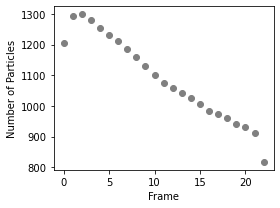

In [488]:
#plot the number of particles in each frame
fig,ax = plt.subplots(1,1,figsize=(4,3))
data_clean_sort = data_clean.sort_values(by = 'frame')
for i in range(data_clean_sort['frame'].max()):
    data_frame = data_clean_sort[data_clean_sort['frame'] == i]
    if len(data_frame) > 0:
        ax.plot(i,len(data_frame),'o',color = 'grey')
#
FrameNumber = data_clean_sort['frame'].max()-data_clean_sort['frame'].min()
MinFrame = data_clean_sort['frame'].min()
#ax.fill_between([MinFrame,MinFrame+FrameNumber*0.6],[0,0],[3500,3500],color = 'gray',alpha = 0.2)
#ax.fill_between([MinFrame+FrameNumber*0.6,MinFrame+FrameNumber*(0.6+0.2)],[0,0],[3500,3500],color = 'tab:blue',alpha = 0.2)
#ax.fill_between([MinFrame+FrameNumber*(0.6+0.2),MinFrame+FrameNumber*(0.6+0.4)],[0,0],[3500,3500],color = 'darkgray',alpha = 0.2)
#ax.plot(data_clean['frame'].unique(),data_clean['frame'].value_counts())
ax.set_xlabel('Frame')
ax.set_ylabel('Number of Particles')
fig.tight_layout()
# plot the first frame

# # plot the last frame
# fig,ax = plt.subplots(1,1,figsize=(8,6))
# ax.scatter(data_clean['x'],data_clean['y'],c=data_clean['frame'],cmap='RdPu',s=2)
# ax.set_xlabel('x')
# ax.set_ylabel('y')
# fig.tight_layout()


3            1
5            1
7            1
8            1
10           1
          ... 
306086    4480
306087    4480
306088    4480
306089    4480
306090    4480
Name: particle, Length: 129932, dtype: int64
      frame  particle           x          y         vx        vy         ax  \
1695    107        16 -125.912862 -58.938750   4.526398 -3.829796  -1.408101   
1698    119        16 -107.152187 -56.008609  11.159436  0.753997 -10.374815   
1701    110        16 -124.453061 -62.901834   0.599315 -5.820496   3.159714   
1702     92        16 -126.102574 -60.170571   0.000000  0.000000   0.000000   
1709    113        16 -121.020727 -61.524622  10.660542  3.320717   7.401684   

            ay  
1695  7.194252  
1698 -9.970068  
1701  9.255330  
1702  0.000000  
1709 -3.387231  


/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_59060/260763064.py:27: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(ax[1].collections[0],label='Frame (normalized)')


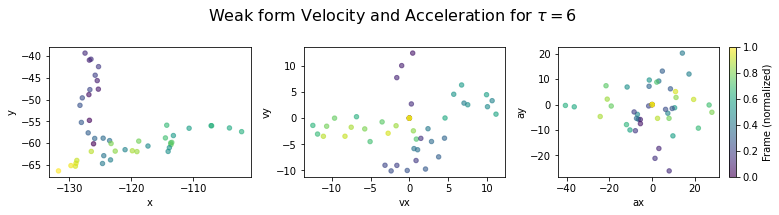

In [16]:
# plotting some acceleration data
#get particle 1
print(data_clean['particle'])
data_1particle = data_clean[data_clean['particle'] == 16]
print(data_1particle.head())

fig,ax = plt.subplots(1,3,figsize=(11,3))
cmap = plt.cm.viridis
normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                    (data_1particle['frame'].max() - data_1particle['frame'].min())
ax[0].scatter(data_1particle['x'],data_1particle['y'],
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].scatter(data_1particle['vx'],data_1particle['vy'],
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[1].set_xlabel('vx')
ax[1].set_ylabel('vy')
ax[2].scatter(data_1particle['ax'], data_1particle['ay'], 
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[2].set_xlabel('ax')
ax[2].set_ylabel('ay')
# ax[1].set_ylim([-2,2])
# ax[1].set_xlim([-2,2])
# ax[0].set_ylim([-1.2,1.2])
# ax[0].set_xlim([-1.2,1.2])
plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
#ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
# put central title for whole figure
if T_Naive:
    fig.suptitle('Naïve Velocity and Acceleration', fontsize=16)
else:
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau =$'+str(tau), fontsize=16)
fig.tight_layout()
scale = 1
if T_weak and T_Naive:
    fig,ax = plt.subplots(1,2,figsize=(8,3))
    cmap = plt.cm.viridis
    normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                        (data_1particle['frame'].max() - data_1particle['frame'].min())
    ax[0].scatter(np.multiply(data_1particle['Wvx'],scale),np.multiply(data_1particle['Wvy'],scale),
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    ax[0].set_xlabel('Wvx')
    ax[0].set_ylabel('Wvy')
    ax[1].scatter(data_1particle['Wax'], data_1particle['Way'], 
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    print(data_1particle['Wax'])
    ax[1].set_xlabel('Wax')
    ax[1].set_ylabel('Way')
    plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
    #ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
    # put central title for whole figure
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau = $'+str(tau), fontsize=16)
    fig.tight_layout()
    ax[1].set_xlabel('ax')
    ax[1].set_ylabel('ay')
    ax[1].set_ylim([-2,2])
    ax[1].set_xlim([-2,2])
    ax[0].set_ylim([-1.2,1.2])
    ax[0].set_xlim([-1.2,1.2])

In [489]:
import AmandaDataGNN.GNN_inference_UD_Masking
importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking)
from AmandaDataGNN.GNN_inference_UD_Masking import *



## Step 2: Build Graph Dataset


In [490]:
# Prepare datast with graph structure
cell_radius = 10.0
N_neighbours = 10
r_cut = cell_radius * N_neighbours
useNeighborList = True
dataset = prepare_dataset(data_clean,cutoff=cell_radius*N_neighbours,max_frames=200,use_neighbor_list=useNeighborList,n_boxes=8,neighbor_rebuild_interval=5,neighbor_domain_margin=5)




Preparing dataset from 24 frames...
processing frame  0
processing frame  1
processing frame  2
processing frame  3
processing frame  4
processing frame  5
processing frame  6
processing frame  7
processing frame  8
processing frame  9
processing frame  10
processing frame  11
processing frame  12
processing frame  13
processing frame  14
processing frame  15
processing frame  16
processing frame  17
processing frame  18
processing frame  19
processing frame  20
processing frame  21
processing frame  22
processing frame  23
Max pairwise distance:  99.9999
x_mean: [-1.3303631e-07  7.6020747e-08] x_std: 261.8702355980621
y_mean: [-0.00030667  0.00354932] y_std: 1.7652826309204102
r_mean: 64.47091674804688 r_std: 24.10112190246582
Dataset prepared: 24 frames
Example - Nodes: (1206, 4), Edges: (2, 99758)
Mask statistics: 6431/25692 nodes included in training (25.0%)


n_neighbors_arr shape: (25692,)
n_neighbors range: 12.0 to 153.0
nn_r_arr shape: (25692,)
nn_r range: 0.652938 to 50.310295
153


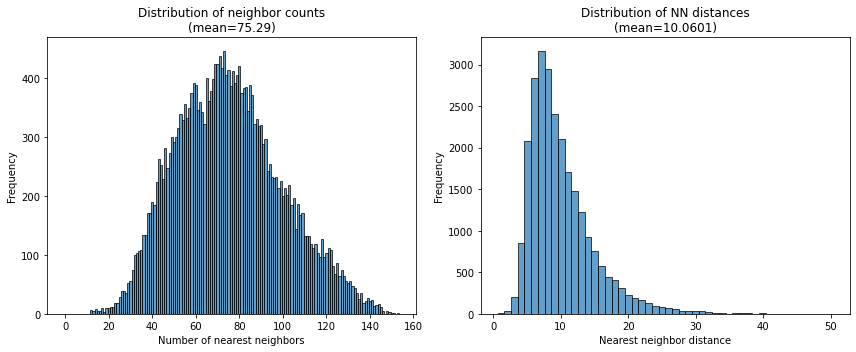

In [491]:
# Flatten n_neighbors_arr (it's a list of arrays, one per frame)
n_neighbors_arr = np.concatenate([d['num_neighbors'] for d in dataset])
print(f"n_neighbors_arr shape: {n_neighbors_arr.shape}")
print(f"n_neighbors range: {n_neighbors_arr.min()} to {n_neighbors_arr.max()}")

#Flatten nn_r_arr (it's now an array per frame, one value per node)
nn_r_arr = np.concatenate([d['nn_r'] for d in dataset])
#Remove NaN values (nodes with no neighbors)
nn_r_arr = nn_r_arr[~np.isnan(nn_r_arr)]
print(f"nn_r_arr shape: {nn_r_arr.shape}")
print(f"nn_r range: {nn_r_arr.min():.6f} to {nn_r_arr.max():.6f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of number of neighbors (use integer bins)
n_neighbors_max = int(n_neighbors_arr.max())
print(n_neighbors_max)
ax[0].hist(n_neighbors_arr, bins=np.arange(-0.5, n_neighbors_max + 1.5, 1), edgecolor='black', alpha=0.7)
ax[0].set_xlabel("Number of nearest neighbors")
ax[0].set_ylabel("Frequency")
ax[0].set_title(f"Distribution of neighbor counts\n(mean={n_neighbors_arr.mean():.2f})")

# Histogram of nearest neighbor distance
ax[1].hist(nn_r_arr, bins=50, edgecolor='black', alpha=0.7)
ax[1].set_xlabel("Nearest neighbor distance")
ax[1].set_ylabel("Frequency")
ax[1].set_title(f"Distribution of NN distances\n(mean={nn_r_arr.mean():.4f})")

fig.tight_layout()
plt.show()



In [101]:
# #take only the last 75 frames of this dataset
max_frame = max(d['frame'] for d in dataset)
min_frame = min(d['frame'] for d in dataset)
print(max_frame)
print(25*6)
# # Filter the dataset to keep only frames > max_frame - 75
dataset_last75 = [d for d in dataset if d['frame'] > max_frame - 75]
dataset_last50 = [d for d in dataset if d['frame'] > max_frame - 50]
dataset_last25 = [d for d in dataset if d['frame'] > max_frame - 25]
# print()


dataset_first75 = [d for d in dataset if d['frame'] < min_frame + 75]
dataset_first50 = [d for d in dataset if d['frame'] < min_frame + 50]
dataset_first25 = [d for d in dataset if d['frame'] < min_frame + 25]

# dataset_25_1 = [d for d in dataset if d['frame'] < min_frame + 25*2 and d['frame'] > min_frame + 25]
# dataset_25_2 = [d for d in dataset if d['frame'] < min_frame + 25*3 and d['frame'] > min_frame + 25*2]
# dataset_25_3 = [d for d in dataset if d['frame'] < min_frame + 25*4 and d['frame'] > min_frame + 25*3]
# dataset_25_4 = [d for d in dataset if d['frame'] < min_frame + 25*5 and d['frame'] > min_frame + 25*4]
# dataset_25_5 = [d for d in dataset if d['frame'] < min_frame + 25*6 and d['frame'] > min_frame + 25*5]

# create 10 rolling frames dataset with 25 frames in each
dataset_rolling = []
for i in range(len(dataset)):
    
    if i < len(dataset) - 5:
        dataset_rolling.append(dataset[i:i+5])
    else:
        break



141
150


In [157]:
train_frac = 1
val_frac = 0.0
test_frac = 0.0
train_data_rolling = []
val_data_rolling = []
test_data_rolling = []
for i in range(len(dataset_rolling)):
    train_0,val_0,test_0 = split_dataset(dataset_rolling[i], train_frac = train_frac,val_frac=val_frac)
    train_data_rolling.append(train_0)
    val_data_rolling.append(val_0)
    test_data_rolling.append(test_0)
print(i)
    

Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0
  Test:  0
Data splits:
  Train: 5
  Val:   0

In [19]:
import pickle
from pathlib import Path
save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/dataIN/")  # or your scratch dir
save_path.mkdir(exist_ok=True)
nameSave_DataIN = "dataIn_Peptide_UD_Naive_Rcut70_Norm.pkl"
#nameSave_DataIN = "dataIn_Peptide_UD_Naive_Rcut60_Norm.pkl"
nameSave_DataIN = "dataIn_EMT_UD_Naive_Rcut70_Norm.pkl"

with open(save_path / nameSave_DataIN, "rb") as f:
    data_loaded = pickle.load(f)

dataset_loaded = data_loaded["dataset"]
meta_loaded     = data_loaded["meta"]

In [492]:
#Split into train/val/test
train_frac = 0.7
val_frac = 0.3
test_frac = 0.0
# max_frame = max(d['frame'] for d in dataset_loaded)
# dataset_loaded_last25 = [d for d in dataset_loaded if d['frame'] > max_frame - 25]
train_data_, val_data_, test_data_, all_data_ = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac)
#print(train_data)

# train_data_0,val_data_0,test_data_0 = split_dataset(dataset_first25, train_frac = train_frac,val_frac=val_frac)
# train_data_1,val_data_1,test_data_1 = split_dataset(dataset_25_1, train_frac = train_frac,val_frac=val_frac)
# train_data_2,val_data_2,test_data_2 = split_dataset(dataset_25_2, train_frac = train_frac,val_frac=val_frac)
# train_data_3,val_data_3,test_data_3 = split_dataset(dataset_25_3, train_frac = train_frac,val_frac=val_frac)
# train_data_4,val_data_4,test_data_4 = split_dataset(dataset_25_4, train_frac = train_frac,val_frac=val_frac)
# train_data_5,val_data_5,test_data_5 = split_dataset(dataset_25_5, train_frac = train_frac,val_frac=val_frac)


Data splits:
  Train: 16
  Val:   7
  Test:  1


In [402]:
#check statitics of graphs
#fig,ax = plt.subplots(1,1,figsize=(4,3))
#print(dataset)
old_dataset =  dataset
#compare old and new dataset
for i in range(len(dataset)):
    frame_data = dataset[i]
    frame_data_old = old_dataset[i] 
    #print(frame_data['num_neighbors'])
    #print(np.shape(frame_data_old['num_neighbors']))
    #neighdataframe = frame_data_old['num_neighbors']
    #print(frame_data_old['num_neighbors'])
    if frame_data['num_neighbors'][0] != frame_data_old['num_neighbors'][0]:
        print(i)
#num_neighs_old= dataset['num_neighbors']
#ax.hist(dataset['num_neighbors'].numpy())

#ax.hist(num_neighs_old)
fig.tight_layout()


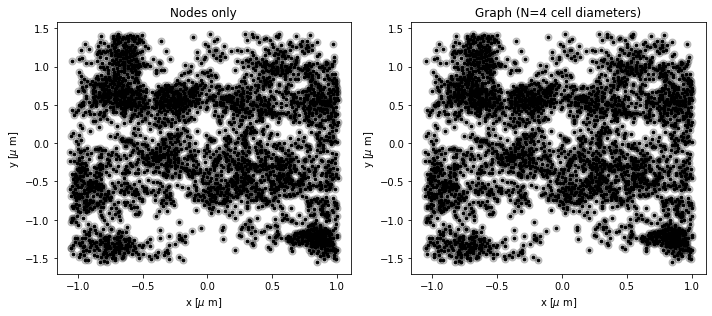

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))

# Get first frame from train_data
frame_data = train_data_[5]  # Fixed: get first element of list

# Plot edges on second subplot
edges = frame_data['edges']
# print("len(edges)",edges.shape[1])
# for i in range(int(edges.shape[1])):
#     if i%1000 == 0:
#         print("i",i)

#     source_idx = edges[0, i]
#     target_idx = edges[1, i]
    
#     # Get positions
#     x_source, y_source = frame_data['nodes'][source_idx][:2] #first two node features are position
#     x_target, y_target = frame_data['nodes'][target_idx][:2]
    
#     # Plot line from source to target
#     ax[1].plot([x_source, x_target], 
#                [y_source, y_target], 
#                color='gray', alpha=0.5, linewidth=0.5)

for i in range(2):
    ax[i].scatter(frame_data['nodes'][:, 0], frame_data['nodes'][:, 1], 
                  color='black', s=7)
    ax[i].scatter(frame_data['nodes'][:, 0], frame_data['nodes'][:, 1], 
                  color='black',alpha = 0.2, s=50)
    ax[i].set_xlabel(r'x [$\mu$ m]')
    ax[i].set_ylabel(r'y [$\mu$ m]')

ax[0].set_title('Nodes only')
ax[1].set_title('Graph (N=4 cell diameters)')
fig.tight_layout()


In [499]:
# import AmandaDataGNN.GNN_inference_OD_Masking
# importlib.reload(AmandaDataGNN.GNN_inference_OD_Masking)
# from AmandaDataGNN.GNN_inference_OD_Masking import *

import AmandaDataGNN.GNN_inference_UD_Masking
importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking)
from AmandaDataGNN.GNN_inference_UD_Masking import *
r_cut = cell_radius * N_neighbours
print(r_cut)
# import AmandaDataGNN.GNN_inference_UD_Masking_f_rxy
# importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking_f_rxy)
# from AmandaDataGNN.GNN_inference_UD_Masking_f_rxy import *

100.0


## Step 3: Create and Train Model


In [500]:
# Create model
model = create_model(hidden_dim=64, gamma_init = 0.01)
# Train model
model, history = train_model(model, train_data_, val_data_, num_epochs=70,far_field_reg = 100,far_field_r = 70,max_r = 120)


ForceGNN model created with hidden_dim=64, gamma_init=0.01
Using r normalisation: mean=64.4709, std=24.1011
Using target normalisation: y_mean=[-0.00030667  0.00354932], y_std=1.76528
Using x normalisation: mean=[-1.3303631e-07  7.6020747e-08], std=261.8702355980621

Training for 70 epochs...


/Users/billiemeadowcroft/opt/anaconda3/lib/python3.8/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Epoch   0: Train Loss = 30.106888, Val Loss = 16.785719
Epoch  10: Train Loss = 3.630775, Val Loss = 4.104374
Epoch  20: Train Loss = 3.567153, Val Loss = 4.054265
Epoch  30: Train Loss = 3.563924, Val Loss = 4.050672
Epoch  40: Train Loss = 3.562976, Val Loss = 4.049910
Epoch  50: Train Loss = 3.562350, Val Loss = 4.050248
Epoch  60: Train Loss = 3.561969, Val Loss = 4.051211
Epoch  69: Train Loss = 3.561908, Val Loss = 4.051569

Training complete!


In [154]:
print(model.x_std)

489.0697


In [107]:
import pickle
from pathlib import Path

# Whatever you like for naming
save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/dataIN/")  # or your scratch dir
save_path.mkdir(exist_ok=True)
max_frames = 200
useNeighborList = True
n_boxes = 8
neighbor_rebuild_interval = 5
neighbor_domain_margin = 3
#nameSave_DataIN = "dataIn_Peptide_UD_Naive_Rcut50_Norm.pkl"
nameSave_DataIN = "dataIn_EMT_UD_weak_Rcut70_Norm.pkl"

dataset_meta = {
    "cutoff": r_cut,
    "max_frames": max_frames,
    "use_neighbor_list": useNeighborList,
    "n_boxes": n_boxes,
    "neighbor_rebuild_interval": neighbor_rebuild_interval,
    "neighbor_domain_margin": neighbor_domain_margin,
}

with open(save_path / nameSave_DataIN, "wb") as f:
    pickle.dump(
        {
            "dataset": dataset,
            "meta": dataset_meta,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

In [396]:

save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/dataIN/")  # or your scratch dir
save_path.mkdir(exist_ok=True)
nameSave_DataIN = "dataIn_Peptide_UD_Naive_Rcut70_Norm.pkl"
nameSave_DataIN = "dataIn_Peptide_UD_Naive_Rcut60_Norm.pkl"

with open(save_path / nameSave_DataIN, "rb") as f:
    data_loaded = pickle.load(f)

dataset = data_loaded["dataset"]
meta     = data_loaded["meta"]

R^2 for ax: -0.0004
R^2 for ay: -0.0004
Average R^2: -0.0004


In [501]:
datasave = '/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/'
name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut70_AllData_reg100_RcutReg100-150"

name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut70_AllData_reg100_RcutReg70-120_NoFenv"
name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut70_AllData_noreg"

name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut50_AllData_reg100_RcutReg50-100"
name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut90_AllData_reg100_RcutReg90-140"
name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut100_AllData_reg100_RcutReg100-150"



name = "model_EMT_UD_Naive_HD64_Epochs70_Rcut70_AllData_reg100_RcutReg70-120"

name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_reg400_RcutReg70-120"
name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_noreg"
name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_reg400_RcutReg70-120_nofenv"
name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_noreg_nofenv"
name = "model_EMT_UD_Weak_HD64_Epochs70_NoInt_OnlyFenv"

name = "model_peptide_UD_Weak_HD64_Epochs70_Rcut70_AllData_reg400_RcutReg70-120"
name = "model_peptide_UD_Weak_HD64_Epochs70_Rcut100_AllData_reg100_RcutReg80-150_MoreReg_IlyaActivations"
name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg80-150_MoreReg_IlyaActivations"
name = "model_Peptide_UD_WeakTau16_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg70-100_MoreReg_IlyaActivations_NoFenv"
save_model(model, datasave+name+'.h5',save_format='weights',history=history)




Model weights saved to: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/model_Peptide_UD_WeakTau16_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg70-100_MoreReg_IlyaActivations_NoFenv.h5
Note: Use load_model() to recreate the model structure and load weights.
Normalisation stats saved to: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/model_Peptide_UD_WeakTau16_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg70-100_MoreReg_IlyaActivations_NoFenv_norm.json
Training history saved to: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/model_Peptide_UD_WeakTau16_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg70-100_MoreReg_IlyaActivations_NoFenv_history.json


In [491]:
# name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut80_AllData_reg100_RcutReg80-130"
# #name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut40_AllData_reg100_RcutReg40-90"
# #name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut50_AllData_reg100_RcutReg50-100"
# #name ="model_Peptide_UD_Naive_HD64_Epochs70_Rcut100_AllData_reg100_RcutReg100-150"
# #name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut70_AllData_noreg"
datasave = '/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/'
name = "model_Peptide_UD_Naive_HD64_Epochs70_Rcut80_AllData_reg100_RcutReg80-130"
name = "model_peptide_UD_Weak_HD64_Epochs70_Rcut70_AllData_reg400_RcutReg70-120"
name = "model_peptide_UD_Weak_HD64_Epochs70_Rcut100_AllData_reg100_RcutReg80-150_MoreReg_IlyaActivations"

loaded_model_pep = load_model(datasave+name+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history_pep = load_history(datasave+name+'_history.json')


name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_reg400_RcutReg70-120"
name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg80-150_MoreReg_IlyaActivations"
#name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_noreg"
#name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_noreg_nofenv"
#name = "model_EMT_UD_Weak_HD64_Epochs70_Rcut70_Last50Frames_reg400_RcutReg70-120_nofenv"
loaded_model_emt = load_model(datasave+name+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history_emt = load_history(datasave+name+'_history.json')

ForceGNN model created with hidden_dim=64, gamma_init=0.01


/Users/billiemeadowcroft/opt/anaconda3/lib/python3.8/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Restored r normalisation: mean=64.4709, std=24.1011
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/model_peptide_UD_Weak_HD64_Epochs70_Rcut100_AllData_reg100_RcutReg80-150_MoreReg_IlyaActivations.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: -0.007803
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/model_peptide_UD_Weak_HD64_Epochs70_Rcut100_AllData_reg100_RcutReg80-150_MoreReg_IlyaActivations_history.json
  Number of epochs: 70
  Final train loss: 1.425542
  Final val loss: 1.385285
ForceGNN model created with hidden_dim=64, gamma_init=0.01
Restored r normalisation: mean=64.1626, std=24.0366
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/model_EMT_UD_Weak_HD64_Epochs70_Rcut100_Last50Frames_reg100_RcutReg80-150_MoreReg_IlyaActivations.h5
  hidden_dim=64, gamm

In [420]:
train_frac = 1
val_frac = 0.
test_frac = 0.
train_dataOUT,val_dataOUT,test_dataOUT,all_dataOUT = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac)

Data splits:
  Train: 50
  Val:   0
  Test:  0


In [502]:
evaluation = evaluate_model(model,train_data_,verbose = False)
predictions = evaluation['predictions']
targets = evaluation['targets']
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")

R^2 for ax: 0.0157
R^2 for ay: 0.0332
Average R^2: 0.0244


In [305]:
max_space = 740.67804
max_pairwise = 1 #49.999992

In [503]:
#max_dist = 1
r_cut = 100 # 120
x_min = -400
x_max = 400
y_min = -400
y_max = 400


print(x_min,x_max,y_min,y_max)
x_arr = np.linspace(x_min,x_max,30)
y_arr = np.linspace(y_min,y_max,40)
x_arr_real = np.linspace(x_min,x_max,40)
y_arr_real = np.linspace(y_min,y_max,40)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_infer_pep = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = 0 #np.multiply(get_force_environment(model, x, y),1)
        #F_env_infer_pep[i,j,:] = np.multiply(get_force_environment(loaded_model_pep, x, y),1)

# Get force at a specific distance

r_arr = np.linspace(0.1,r_cut,100)
force_infer = []
force_infer_100 = []
force_infer_m100 = []
force_infer_pep = []
for r in r_arr:
    force_infer.append(get_force_at_distance(model, r)) #
    #force_infer_100.append(get_force_at_distance(model, r,100,100,100,100))
    #force_infer_m100.append(get_force_at_distance(model, r,-100,-100,-100,-100))
    #force_infer_pep.append(get_force_at_distance(loaded_model_pep, r))

r_arr_plot = np.multiply(r_arr,1)

# === 1) Magnitude of the force ===
F_mag_pep = np.linalg.norm(F_env_infer_pep, axis=2)  # shape (len(x_arr), len(y_arr))
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')

-400 400 -400 400


Gamma:0.052


/Users/billiemeadowcroft/opt/anaconda3/lib/python3.8/site-packages/matplotlib/quiver.py:689: RuntimeWarning: divide by zero encountered in double_scalars
  length = a * (widthu_per_lenu / (self.scale * self.width))
/Users/billiemeadowcroft/opt/anaconda3/lib/python3.8/site-packages/matplotlib/quiver.py:689: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


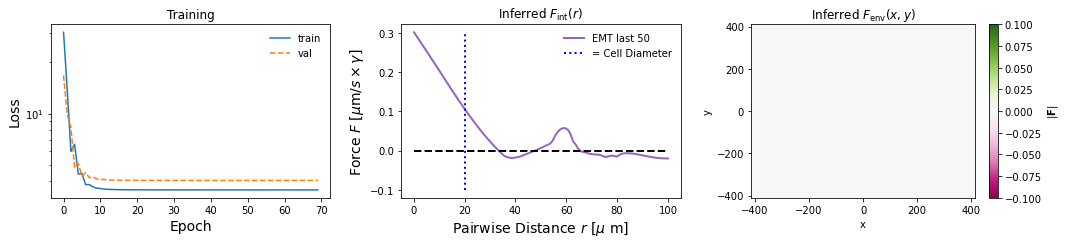

In [504]:
# Plot training history
fig,ax  = plt.subplots(1,3,figsize = (15,3.5))
#history = loaded_model_history
Gamma = -get_gamma(model)

text1 = "Gamma:"+str(np.round(Gamma,3))

scaleF = 1
print(text1)
#ax[0].plot(loaded_model_history_emt['train_loss'],color = clrs[0],linestyle = '-',label = 'train')
#ax[0].plot(loaded_model_history_emt['val_loss'],color = clrs[1],linestyle = '--',label = 'val')
ax[0].plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train')
ax[0].plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val')
#ax[0].text(10,np.min(loaded_model_history_emt['train_loss'])*0.995+1,text1)
ax[0].legend(frameon = False)
ax[0].set_yscale('log')
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel('Loss',fontsize = 14)
ax[1].plot(r_arr_plot,np.multiply(force_infer,scaleF),color = 'tab:purple',linestyle = '-',linewidth = 2,label = 'EMT last 50')
#ax[1].plot(r_arr_plot,np.multiply(force_infer_100,scaleF),color = clrs[1],linestyle = '-',linewidth = 2,label = '100,100')
#ax[1].plot(r_arr_plot,np.multiply(force_infer_m100,scaleF),color = clrs[2],linestyle = '-',linewidth = 2,label = '-100,-100')
#ax[1].plot(r_arr_plot,np.multiply(force_infer_pep,scaleF),color ='tab:green',linestyle = '-',linewidth = 2,label = 'Peptide')
ax[1].set_xlabel(r'Pairwise Distance $r$ [$\mu$ m]',fontsize = 14)
ax[1].set_ylabel(r'Force $F$ [$\mu$m$/s \times \gamma$]',fontsize = 14)
ax[1].plot([0,r_cut],[0,0],color = 'black',linestyle = '--',linewidth = 2)
ax[1].plot([20,20],[-0.1,0.3],color = 'blue',linestyle = ':',linewidth = 2,label = "= Cell Diameter")
ax[1].legend(frameon = False)
#ax[1].set_ylim([-0.2,0.5])
pcm = ax[2].pcolormesh(X, Y, F_mag, shading='auto', cmap='PiYG')
cbar = fig.colorbar(pcm, ax=ax[2])
cbar.set_label(r'$|\mathbf{F}|$')

# === 3) Quiver on top ===
# (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 20, 1)
sy = max(len(y_arr) // 20, 1)

ax[2].quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    F_env_infer[::sx, ::sy, 0],
    F_env_infer[::sx, ::sy, 1],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=None,   # or a number if you want to shrink arrows
    width=0.003
)

# === 4) Axes labels / ticks ===
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
#ax[1].set_ylim([-0.1,0.1])
#ax[0].set_yscale('log')
ax[2].set_title(r'Inferred $F_{\mathrm{env}}(x,y)$')
ax[1].set_title(r'Inferred $F_{\mathrm{int}}(r)$')
ax[0].set_title(r'Training')
fig.tight_layout()
#fig.savefig(datasave+'F_env_infer.png',dpi=1000)




In [494]:
# across these dataframes

# Collect positions from multiple frames
xs = []
ys = []

for frame_data in train_data:   # or train_data[::5] to subsample time
    xs.append(frame_data['nodes'][:, 0])
    ys.append(frame_data['nodes'][:, 1])

xs = np.concatenate(xs)
ys = np.concatenate(ys)

nbins = 50  # adjust resolution

H, xedges, yedges = np.histogram2d(
    xs, ys,
    bins=nbins
)



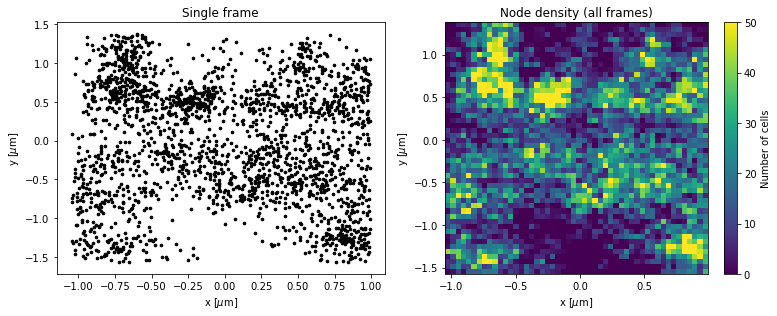

In [495]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# ---- LEFT: snapshot scatter ----
frame_data = train_data[5]

ax[0].scatter(frame_data['nodes'][:, 0],
              frame_data['nodes'][:, 1],
              s=7, color='black')
ax[0].set_xlabel(r'x [$\mu$m]')
ax[0].set_ylabel(r'y [$\mu$m]')
ax[0].set_title("Single frame")

# ---- RIGHT: density histogram ----
im = ax[1].imshow(
    H.T,                       # transpose so x/y align correctly
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
    vmin = 0,
    vmax = 50
)

ax[1].set_xlabel(r'x [$\mu$m]')
ax[1].set_ylabel(r'y [$\mu$m]')
ax[1].set_title("Node density (all frames)")

cbar = fig.colorbar(im, ax=ax[1])
cbar.set_label("Number of cells")

plt.tight_layout()
plt.show()


In [425]:
import AmandaDataGNN.GNN_inference_UD_Masking
importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking)
from AmandaDataGNN.GNN_inference_UD_Masking import *

In [426]:
# Evaluate on test data
#data_trains = train_data_rolling #[train_data_0,train_data_1,train_data_2,train_data_3,train_data_4,train_data_5]
r_squares = []
r_squares_ax = []
r_squares_ay = []
#for i in range(len(data_trains)):
evaluation = evaluate_model(model,train_data_,verbose = False)
#print("Evaluating ",i,"out of ",len(data_trains))

# Plot predictions vs actual
#plot_predictions(evaluation)
predictions = evaluation['predictions']
targets = evaluation['targets']
# fig,ax = plt.subplots(1,2,figsize = (8,3))
# ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = clrs[2],linestyle = '',markersize = 2)
# ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
# ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = clrs[2],linestyle = '',markersize = 2)
# ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
# ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
# ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
# ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
# ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
# ax[0].legend(frameon = False)
# fig.tight_layout()

# calculate R^2 (on test data)
# R^2 = 1 - (sum((y_true - y_pred)**2)) / (sum((y_true - y_mean)**2))
# R^2 = 1- evaluation['mse']/\sum(targets-np.mean(targets))**2
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)

print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")
#ax[0].set_ylim([-1,1])
r_squares.append((rsq_ax+rsq_ay)/2)
r_squares_ax.append(rsq_ax)
r_squares_ay.append(rsq_ay)

R^2 for ax: 0.0073
R^2 for ay: 0.0076
Average R^2: 0.0075


In [144]:
print(r_squares)
print(r_squares_ax)
print(r_squares_ay)


[-0.0010873675346374512, -0.001514136791229248, 0.0016903579235076904, 0.0013120770454406738, 0.0019889771938323975, 0.0023269355297088623, 0.002763897180557251, 0.0017250776290893555, 0.0023109614849090576, 0.0024184584617614746, 0.0020787715911865234, 0.0007348358631134033, 0.0008883476257324219, 0.0014117062091827393]
[-0.0027483701705932617, -0.00255429744720459, 0.0025709867477416992, 0.0015848875045776367, 0.0018821954727172852, 0.0027173757553100586, 0.003522217273712158, 0.0009191632270812988, 0.0029754042625427246, 0.0030057430267333984, 0.002973198890686035, 0.001704394817352295, 0.0006610751152038574, 0.0016518235206604004]
[0.0005736351013183594, -0.00047397613525390625, 0.0008097290992736816, 0.001039266586303711, 0.0020957589149475098, 0.001936495304107666, 0.0020055770874023438, 0.002530992031097412, 0.0016465187072753906, 0.0018311738967895508, 0.0011843442916870117, -0.00023472309112548828, 0.0011156201362609863, 0.0011715888977050781]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'per_dim_var': array([1.6544759, 1.6228079], dtype=float32), 'per_dim_std': array([1.2862643, 1.2738948], dtype=float32), 'overall_rms': 1.8103184700012207, 'num_samples': 53512, 'num_frames': 35, 'mean_residual': array([-0.00066545,  0.00127081], dtype=float32)}


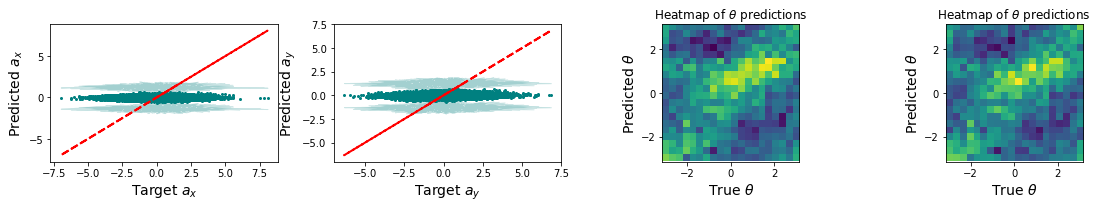

In [464]:
# visualise the y_pred vs y_true and put in a band for the noise on y_pred
evaluation = evaluate_model(model,train_data_,verbose = False)

predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model, train_data_)
print(Overall_noise)

fig,ax = plt.subplots(1,4,figsize = (16,3))
ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = 'teal',linestyle = '',markersize = 2)
ax[0].fill_between(targets[:, 0],predictions[:, 0]-Overall_noise['per_dim_std'][0],predictions[:, 0]+Overall_noise['per_dim_std'][0],color = 'teal',alpha = 0.2)
ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = 'teal',linestyle = '',markersize = 2)
ax[1].fill_between(targets[:, 1],predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 1]+Overall_noise['per_dim_std'][1],color = 'teal',alpha = 0.2)
ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
ax[0].legend(frameon = False)
#predicted direction \theta vs true direction \theta
theta_pred = np.arctan2(predictions[:, 1],predictions[:, 0])
theta_true = np.arctan2(targets[:, 1],targets[:, 0])
theta_pred_upper = np.arctan2(predictions[:, 1]+Overall_noise['per_dim_std'][1],predictions[:, 0]-Overall_noise['per_dim_std'][0])
theta_pred_lower = np.arctan2(predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 0]+Overall_noise['per_dim_std'][0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
#mask out thetas from accelerations < 0.5
amin = 1
valid = a_mag > amin
theta_true_valid = theta_true[valid]
theta_pred_valid = theta_pred[valid]
theta_pred_upper_valid = theta_pred_upper[valid]
theta_pred_lower_valid = theta_pred_lower[valid]

# make this one a heatmap
heatmap, xedges, yedges = np.histogram2d(theta_true, theta_pred, bins=20)

ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[2].set_title(r'Heatmap of $\theta$ predictions')

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[3].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[3].set_xlabel(r'True $\theta$',fontsize = 14)
ax[3].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[3].set_title(r'Heatmap of $\theta$ predictions')

# ax[2].plot(theta_true,theta_pred,'o',color = 'teal',linestyle = '',markersize = 2)
# ax[2].fill_between(theta_true,theta_pred_lower,theta_pred_upper,color = 'teal',alpha = 0.2)
# ax[2].plot(theta_true,theta_true,'r--',linewidth = 2)
# ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
# ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
fig.tight_layout()




In [356]:
print(Overall_noise['per_dim_std'][1])

1.0833822499158943


{'per_dim_var': array([1.6544759, 1.6228079], dtype=float32), 'per_dim_std': array([1.2862643, 1.2738948], dtype=float32), 'overall_rms': 1.8103184700012207, 'num_samples': 53512, 'num_frames': 35, 'mean_residual': array([-0.00066545,  0.00127081], dtype=float32)}


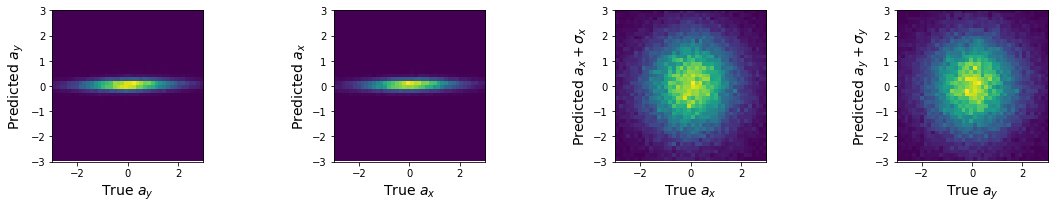

In [465]:
# visualise the y_pred vs y_true and put in a band for the noise on y_pred
evaluation = evaluate_model(model,train_data_,verbose = False)

predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model, train_data_)
print(Overall_noise)

fig,ax = plt.subplots(1,4,figsize = (16,3))
# ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = 'teal',linestyle = '',markersize = 2)
# ax[0].fill_between(targets[:, 0],predictions[:, 0]-Overall_noise['per_dim_std'][0],predictions[:, 0]+Overall_noise['per_dim_std'][0],color = 'teal',alpha = 0.2)
# ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
# ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = 'teal',linestyle = '',markersize = 2)
# ax[1].fill_between(targets[:, 1],predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 1]+Overall_noise['per_dim_std'][1],color = 'teal',alpha = 0.2)
# ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
# ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
# ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
# ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
# ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
# ax[0].legend(frameon = False)





# Compute common limits
vmin =-3 # min(targets[:, 1].min(), predictions[:, 1].min())
vmax =3 # max(targets[:, 1].max(), predictions[:, 1].max())

# Square histogram
heatmap, xedges, yedges = np.histogram2d(
    targets[:, 1],
    predictions[:, 1],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[0].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[0].set_xlabel(r'True $a_y$', fontsize=14)
ax[0].set_ylabel(r'Predicted $a_y$', fontsize=14)
#ax[0].set_title(r'Heatmap of $a_y$ predictions')

# Compute common limits
vmin = -3 #min(targets[:, 0].min(), predictions[:, 0].min())
vmax = 3 #max(targets[:, 0].max(), predictions[:, 0].max())

# Square histogram
heatmap, xedges, yedges = np.histogram2d(
    targets[:, 0],
    predictions[:, 0],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[1].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[1].set_xlabel(r'True $a_x$', fontsize=14)
ax[1].set_ylabel(r'Predicted $a_x$', fontsize=14)
#ax[1].set_title(r'Heatmap of $a_x$ predictions')


# Square histogram
#make fake gaussian noise predictions

predictions_fake = np.zeros(predictions.shape)
for i in range(len(predictions)):
    predictions_fake[i,1] = predictions[i,1] + np.random.normal(0,Overall_noise['per_dim_std'][1])
    predictions_fake[i,0] = predictions[i,0] + np.random.normal(0,Overall_noise['per_dim_std'][0])
heatmap, xedges, yedges = np.histogram2d(
    targets[:, 0],
    predictions_fake[:, 0],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[2].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[2].set_xlabel(r'True $a_x$', fontsize=14)
ax[2].set_ylabel(r'Predicted $a_x +\sigma_x$', fontsize=14)
#ax[2].set_title(r'Heatmap of $a_x+\sigma_x$ predictions')


# Square histogram

heatmap, xedges, yedges = np.histogram2d(
    targets[:, 1],
    predictions_fake[:, 1],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[3].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[3].set_xlabel(r'True $a_y$', fontsize=14)
ax[3].set_ylabel(r'Predicted $a_y +\sigma_y$', fontsize=14)
#ax[3].set_title(r'Heatmap of $a_y+\sigma_y$ predictions')




# ax[2].plot(theta_true,theta_pred,'o',color = 'teal',linestyle = '',markersize = 2)
# ax[2].fill_between(theta_true,theta_pred_lower,theta_pred_upper,color = 'teal',alpha = 0.2)
# ax[2].plot(theta_true,theta_true,'r--',linewidth = 2)
# ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
# ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
fig.tight_layout()




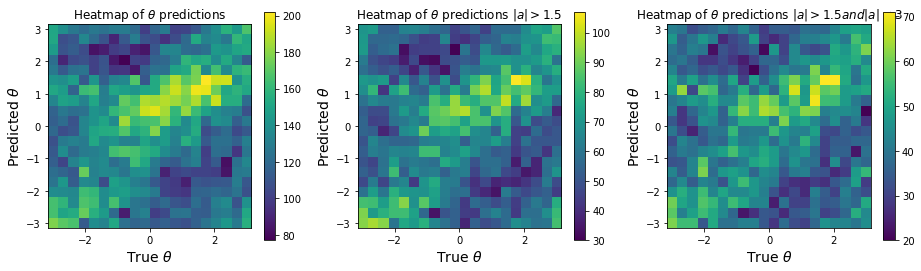

In [466]:
#predicted direction \theta vs true direction \theta

fig,ax = plt.subplots(1,3,figsize = (13,4))

theta_pred = np.arctan2(predictions[:, 1],predictions[:, 0])
theta_true = np.arctan2(targets[:, 1],targets[:, 0])
theta_pred_upper = np.arctan2(predictions[:, 1]+Overall_noise['per_dim_std'][1],predictions[:, 0]-Overall_noise['per_dim_std'][0])
theta_pred_lower = np.arctan2(predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 0]+Overall_noise['per_dim_std'][0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
#mask out thetas from accelerations < 0.5
amin = 1.5
valid_1 = a_mag > amin
amax = 2.5
valid_2 = a_mag < amax
valid = valid_1 & valid_2

theta_true_valid = theta_true[valid_1]
theta_pred_valid = theta_pred[valid_1]
theta_pred_upper_valid = theta_pred_upper[valid_1]
theta_pred_lower_valid = theta_pred_lower[valid_1]

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[1].set_xlabel(r'True $\theta$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[1].set_title(r'Heatmap of $\theta$ predictions $|a|>1.5$')
cbar = fig.colorbar(ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[1], shrink=0.9)

theta_true_valid = theta_true[valid]
theta_pred_valid = theta_pred[valid]
theta_pred_upper_valid = theta_pred_upper[valid]
theta_pred_lower_valid = theta_pred_lower[valid]

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[2].set_title(r'Heatmap of $\theta$ predictions $|a|>1.5 and |a|<3$')
cbar = fig.colorbar(ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[2], shrink=0.9)

heatmap, xedges, yedges = np.histogram2d(theta_true, theta_pred, bins=20)
ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[0].set_xlabel(r'True $\theta$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[0].set_title(r'Heatmap of $\theta$ predictions')
cbar = fig.colorbar(ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[0], shrink=0.9)

#make all colourbars the same








fig.tight_layout()



Fetching 1 example of a poor prediction

26803 49399


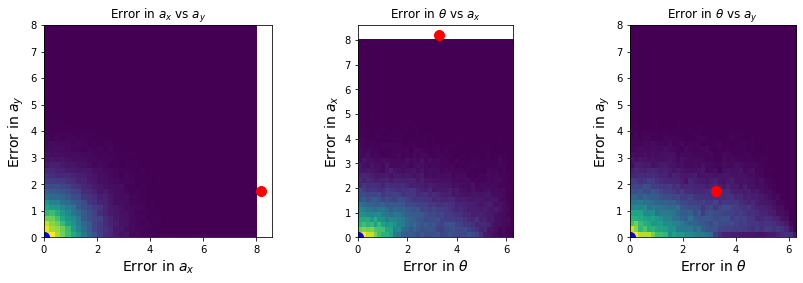

In [467]:
#make a list of error in a_x, a_y, theta
error_a_x = np.abs(predictions[:, 0] - targets[:, 0])
error_a_y = np.abs(predictions[:, 1] - targets[:, 1])
error_theta = np.abs(theta_pred - theta_true)
#make a histogram of error_a_x, error_a_y, error_theta

#choose a point which has high error in a_x, a_y, theta
error_a_x_norm = error_a_x / np.mean(error_a_x)
error_a_y_norm = error_a_y / np.mean(error_a_y)
error_theta_norm = error_theta / np.mean(error_theta)
Overall_error = np.sqrt(error_a_x_norm**2 + error_a_y_norm**2+error_theta_norm**2)
idx_max = np.argmax(Overall_error)
idx_min = np.argmin(Overall_error)
max_err = 8
fig,ax = plt.subplots(1,3,figsize = (12,4))
heatmap, xedges, yedges = np.histogram2d(error_a_x,error_a_y,bins=40,range=[[0, max_err], [0, max_err]])
ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[0].set_xlabel(r'Error in $a_x$',fontsize = 14)
ax[0].set_ylabel(r'Error in $a_y$',fontsize = 14)
ax[0].set_title(r'Error in $a_x$ vs $a_y$')

heatmap, xedges, yedges = np.histogram2d(error_theta,error_a_x,bins=40,range=[[0, 2*np.pi], [0, max_err]])
ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[1].set_xlabel(r'Error in $\theta$',fontsize = 14)
ax[1].set_ylabel(r'Error in $a_x$',fontsize = 14)
ax[1].set_title(r'Error in $\theta$ vs $a_x$')

heatmap, xedges, yedges = np.histogram2d(error_theta,error_a_y,bins=40,range=[[0, 2*np.pi], [0, max_err]])
ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'Error in $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Error in $a_y$',fontsize = 14)
ax[2].set_title(r'Error in $\theta$ vs $a_y$')





ax[0].plot(error_a_x[idx_max],error_a_y[idx_max],'o',color = 'red',markersize = 10)
ax[0].plot(error_a_x[idx_min],error_a_y[idx_min],'o',color = 'blue',markersize = 10)
ax[1].plot(error_theta[idx_max],error_a_x[idx_max],'o',color = 'red',markersize = 10)
ax[1].plot(error_theta[idx_min],error_a_x[idx_min],'o',color = 'blue',markersize = 10)
ax[2].plot(error_theta[idx_max],error_a_y[idx_max],'o',color = 'red',markersize = 10)
ax[2].plot(error_theta[idx_min],error_a_y[idx_min],'o',color = 'blue',markersize = 10)
print(idx_max,idx_min)
fig.tight_layout()



In [468]:
import AmandaDataGNN.GNN_inference_UD_Masking
importlib.reload(AmandaDataGNN.GNN_inference_UD_Masking)
from AmandaDataGNN.GNN_inference_UD_Masking import *

In [469]:
train_dataOUT,val_dataOUT,test_dataOUT, allNoShuffleOUT = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac)
# evaluation = evaluate_model_frames(model,allNoShuffleOUT,verbose = False)

# predictions = evaluation['predictions']
# targets = evaluation['targets']

Data splits:
  Train: 50
  Val:   0
  Test:  0


In [470]:
df_og_with_error = evaluate_model_frames(model,allNoShuffleOUT,verbose = False)

Index(['frame', 'node_id', 'x', 'y', 'num_neighbors', 'nn_r', 'error',
       'error_theta', 'error_x', 'error_y', 'pred_x', 'pred_y', 'target_x',
       'target_y'],
      dtype='object')
34


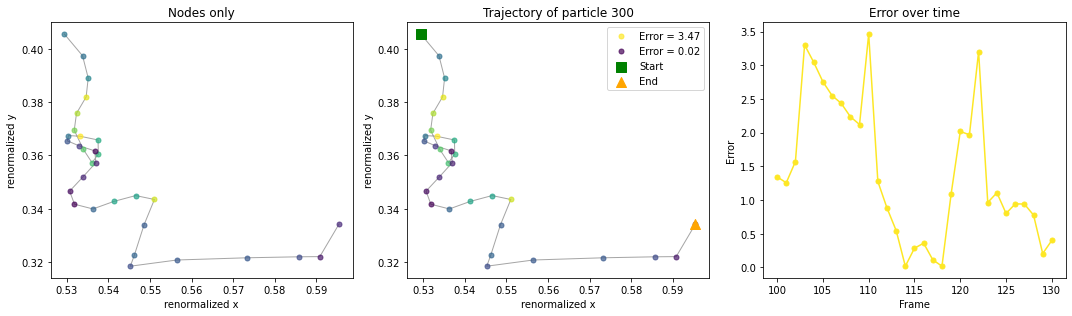

In [471]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
print(df_og_with_error.columns)
# Get first frame from train_data
frame_data = df_og_with_error[df_og_with_error['frame'] == 137]  # Fixed: get first element of list
print(len(df_og_with_error['frame'].unique()))
# Plot edges on second subplot


for i in range(1):
    ax[i].scatter(frame_data['x'], frame_data['y'], 
                  color='black', s=7)
    ax[i].scatter(frame_data['x'], frame_data['y'], 
                  color='black',alpha = 0.2, s=50)
    ax[i].set_xlabel(r'x [$\mu$ m]')
    ax[i].set_ylabel(r'y [$\mu$ m]')

#plot one node over time 
particle_id = 300
x_positions = []
y_positions = []

# Loop through all frames to find this particle
#sort data by frame
allNoShuffleOUT = sorted(allNoShuffleOUT, key=lambda x: x['frame'])


# Plot one node over time using the DataFrame
particle_ids = [300]
cmap = plt.cm.viridis
# Filter the DataFrame for this particle_id and sort by frame
count = 0
error_type = 'error_theta'
for particle_id in particle_ids:
    count+=1
    err_time_arr = []
    frames_arr = []
    particle_data = df_og_with_error[df_og_with_error['node_id'] == particle_id].sort_values('frame')
    if len(particle_data) > 0:
    # Plot using predicted positions (or use 'target_x', 'target_y' for true positions)
        ax[1].plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax[0].plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', linewidth=1, alpha=0.7)
        max_err = particle_data[error_type].max()
        min_err = particle_data[error_type].min()
        for xx in range(len(particle_data)):
            if particle_data[error_type].iloc[xx]==max_err or particle_data[error_type].iloc[xx]==min_err:
                ax[1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7,label = "Error = "+str(np.round(particle_data[error_type].iloc[xx],2)))
            
            else:
                ax[1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
            ax[0].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
            err_time_arr.append(particle_data[error_type].iloc[xx])
            frames_arr.append(particle_data['frame'].iloc[xx])
        ax[2].plot(frames_arr,err_time_arr,'o',color = cmap(count/len(particle_ids)),markersize = 5,linestyle ='-')
        
        # Optional: Also plot true positions
        # ax[1].plot(particle_data['target_x'], particle_data['target_y'], 's-', 
        #            color='blue', markersize=3, linewidth=1, alpha=0.5, label='True')
        
        # Mark start and end
        ax[1].scatter(particle_data['x'].iloc[0], particle_data['y'].iloc[0], 
                    color='green', s=100, marker='s', label='Start', zorder=5)
        ax[1].scatter(particle_data['x'].iloc[-1], particle_data['y'].iloc[-1], 
                    color='orange', s=100, marker='^', label='End', zorder=5)
        ax[1].legend()
    else:
        print(f"Particle {particle_id} not found in DataFrame")

ax[0].set_title('Nodes only')
ax[1].set_title('Trajectory of particle 300')
ax[2].set_title('Error over time')
ax[1].set_xlabel("renormalized x")
ax[1].set_ylabel("renormalized y")
ax[0].set_xlabel("renormalized x")
ax[0].set_ylabel("renormalized y")
ax[2].set_xlabel("Frame")
ax[2].set_ylabel(r"Error")

fig.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


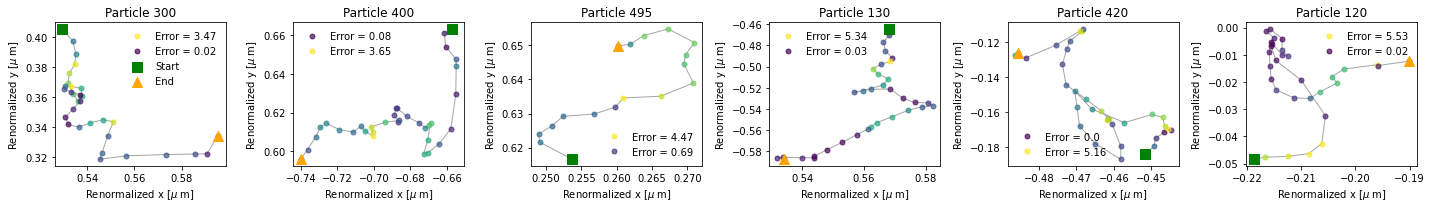

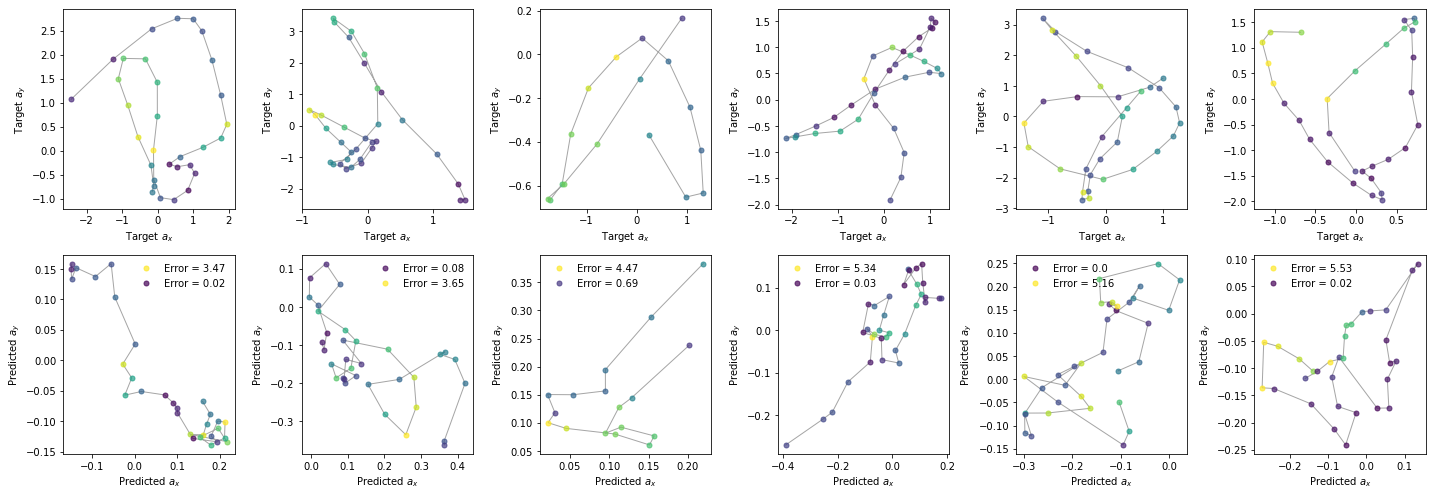

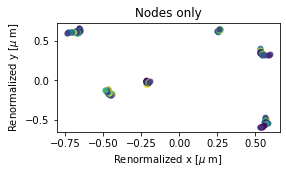

In [472]:
fig, ax = plt.subplots(1, 6, figsize=(20, 3))
fig2, ax2 = plt.subplots(2, 6, figsize=(20, 7))
particle_ids = [300,400,495,130,420,120]
fig0,ax0 = plt.subplots(1,1,figsize = (4,2))
count = 0
for particle_id in particle_ids:
    count+=1
    err_time_arr = []
    frames_arr = []
    particle_data = df_og_with_error[df_og_with_error['node_id'] == particle_id].sort_values('frame')
    if len(particle_data) > 0:
    # Plot using predicted positions (or use 'target_x', 'target_y' for true positions)
        ax[count-1].plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax2[0,count-1].plot(particle_data['target_x'], particle_data['target_y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax2[1,count-1].plot(particle_data['pred_x'], particle_data['pred_y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax0.plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', linewidth=1, alpha=0.7)
        max_err = particle_data[error_type].max()
        min_err = particle_data[error_type].min()
        for xx in range(len(particle_data)):
            if particle_data[error_type].iloc[xx]==max_err or particle_data[error_type].iloc[xx]==min_err:
                ax[count-1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7,label = "Error = "+str(np.round(particle_data[error_type].iloc[xx],2)))
                ax2[0,count-1].plot(particle_data['target_x'].iloc[xx], particle_data['target_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                ax2[1,count-1].plot(particle_data['pred_x'].iloc[xx], particle_data['pred_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7,label = "Error = "+str(np.round(particle_data[error_type].iloc[xx],2)))
            
            else:
                ax[count-1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                ax2[0,count-1].plot(particle_data['target_x'].iloc[xx], particle_data['target_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                ax2[1,count-1].plot(particle_data['pred_x'].iloc[xx], particle_data['pred_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
            ax0.plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                    
            err_time_arr.append(particle_data[error_type].iloc[xx])
            frames_arr.append(particle_data['frame'].iloc[xx])
        #ax[2].plot(frames_arr,err_time_arr,'o',color = cmap(count/len(particle_ids)),markersize = 5,linestyle ='-')
        
        # Optional: Also plot true positions
        # ax[1].plot(particle_data['target_x'], particle_data['target_y'], 's-', 
        #            color='blue', markersize=3, linewidth=1, alpha=0.5, label='True')
        
        # Mark start and end
        if count==1:
            ax[count-1].scatter(particle_data['x'].iloc[0], particle_data['y'].iloc[0], 
                        color='green', s=100, marker='s',label = 'Start', zorder=5)
            ax[count-1].scatter(particle_data['x'].iloc[-1], particle_data['y'].iloc[-1], 
                        color='orange', s=100, marker='^',label = 'End', zorder=5)
        else:
            ax[count-1].scatter(particle_data['x'].iloc[0], particle_data['y'].iloc[0], 
                        color='green', s=100, marker='s', zorder=5)
            ax[count-1].scatter(particle_data['x'].iloc[-1], particle_data['y'].iloc[-1], 
                        color='orange', s=100, marker='^', zorder=5)
        ax[count-1].legend(frameon=False)
        ax[count-1].set_xlabel("Renormalized x [$\mu$ m]")
        ax[count-1].set_ylabel("Renormalized y [$\mu$ m]")
        ax[count-1].set_title(f"Particle {particle_id}")
        ax2[0,count-1].legend(frameon=False)
        ax2[1,count-1].legend(frameon=False)
        ax2[0,count-1].set_xlabel(r"Target $a_{x}$")
        ax2[0,count-1].set_ylabel("Target $a_{y}$")
        ax2[1,count-1].set_xlabel("Predicted $a_{x}$")
        ax2[1,count-1].set_ylabel("Predicted $a_{y}$")
    else:
        print(f"Particle {particle_id} not found in DataFrame")

ax0.set_title('Nodes only')
ax0.set_xlabel("Renormalized x [$\mu$ m]")
ax0.set_ylabel("Renormalized y [$\mu$ m]")

fig.tight_layout()
fig2.tight_layout()

NumCells 2950
min frames 100
Pearson correlation: 0.021978159123972368
min num_frames_arr 1
max num_frames_arr 34
min av_err_time_arr 1.1632409364946428
max av_err_time_arr 2.137100903756947
Pearson correlation: 0.0021065754437515232
x_range > y_range
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,

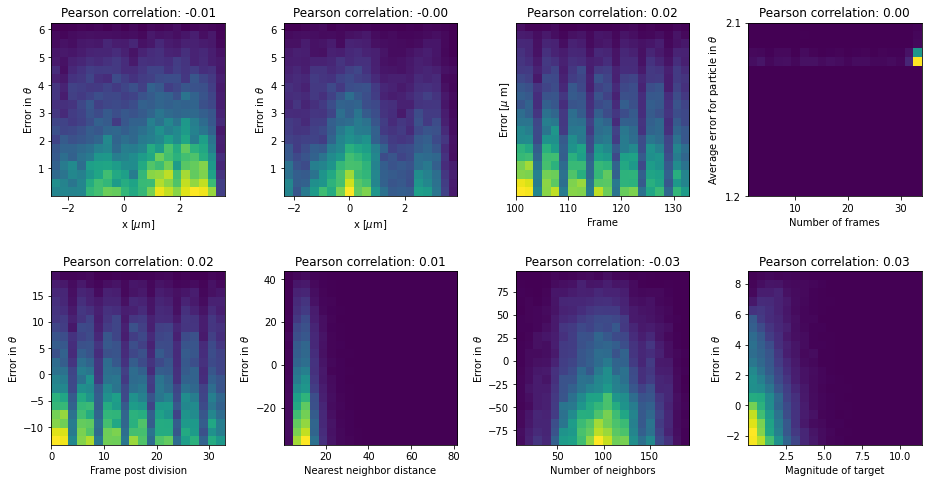

In [473]:
#Choose 30 random cells
#make arrays of x,y,error_a_x,error_a_y,error_theta,number of frames,frame number,local density,lifetime,n_neighbors_1hop
NumCells = len(df_og_with_error['node_id'].unique())
Ncells = NumCells #4000
print("NumCells",NumCells)
fig,ax = plt.subplots(2,4,figsize = (13,7))
err_time_arr = []
err_time_post_Div = []
frame_post_Div = []
frames_arr = []
x_pos_arr = []
y_pos_arr = []
av_err_time_arr = []
num_frames_arr = []
nn_r_arr = []
num_neighbors_arr = []
mag_target_arr = [] 
Nbins=20
counter = 0
error_type = 'error_theta'
for ii in range(Ncells):
    
    
    #choose a random cell
    # go through cells in order
    cell_idx = ii
    cell_data = df_og_with_error[df_og_with_error['node_id'] == cell_idx].sort_values('frame')
    if len(cell_data) > 0:
        for xx in range(len(cell_data)):
            err_time_arr.append(cell_data[error_type].iloc[xx])
            frames_arr.append(cell_data['frame'].iloc[xx])
            x_pos_arr.append(np.abs(cell_data['x'].iloc[xx]))
            y_pos_arr.append(np.abs(cell_data['y'].iloc[xx]))
            nn_r_arr.append(cell_data['nn_r'].iloc[xx])
            num_neighbors_arr.append(cell_data['num_neighbors'].iloc[xx])
            target_x = cell_data['target_x'].iloc[xx]
            target_y = cell_data['target_x'].iloc[xx]
            mag_target = np.sqrt(target_x**2+target_y**2)
            mag_target_arr.append(mag_target)
            # run through n_neighbors_1hop
            
            if np.min(cell_data['frame'])>92:
                err_time_post_Div.append(cell_data[error_type].iloc[xx])
                frame_post_Div.append(cell_data['frame'].iloc[xx]-np.min(cell_data['frame']))

        av_err_time_arr.append(np.mean(err_time_arr))
        num_frames_arr.append(len(cell_data))



        #ax[ii].plot(frames_arr,err_time_arr,'o',color = 'grey',markersize = 5,linewidth = 1,alpha = 0.7)
        #ax[ii].set_xlabel("Frame")
    else:
        counter+=1
    #    print(f"Particle {cell_idx} not found in DataFrame")
    #ax[ii].set_ylabel("Error in $\theta$")
    #ax[ii].set_title(f"Particle {cell_idx}")
heatmap, xedges, yedges = np.histogram2d(x_pos_arr,err_time_arr,bins=Nbins,range=[[np.min(x_pos_arr) ,np.max(x_pos_arr)], [np.min(err_time_arr), np.max(err_time_arr)]])
corr_pearson = np.corrcoef(x_pos_arr,err_time_arr)[0,1]
x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    x_min_plot = x_min
    x_max_plot = x_max

im = ax[0,0].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min, y_max],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[0,0].set_xlabel(r"x [$\mu$m]")
ax[0,0].set_ylabel(r"Error in $\theta$")
ax[0,0].set_title(f"Pearson correlation: {corr_pearson:.2f}")

heatmap, xedges, yedges = np.histogram2d(y_pos_arr,err_time_arr,bins=Nbins,range=[[np.min(y_pos_arr) ,np.max(y_pos_arr)], [np.min(err_time_arr), np.max(err_time_arr)]])
corr_pearson = np.corrcoef(y_pos_arr,err_time_arr)[0,1]
x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    x_min_plot = x_min
    x_max_plot = x_max

im = ax[0,1].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min, y_max],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[0,1].set_xlabel(r"x [$\mu$m]")
ax[0,1].set_ylabel(r"Error in $\theta$")
ax[0,1].set_title(f"Pearson correlation: {corr_pearson:.2f}")




heatmap, xedges, yedges = np.histogram2d(frames_arr,err_time_arr,bins=Nbins,range=[[np.min(frames_arr),np.max(frames_arr)], [np.min(err_time_arr), np.max(err_time_arr)]])
#correlation between num_frames_arr and av_err_time_arr
corr_pearson = np.corrcoef(frames_arr,err_time_arr)[0,1]
print("min frames",np.min(frames_arr))
#corr_spearman = np.corrcoef(num_frames_arr,av_err_time_arr,method='spearman')[0,1]
print(f"Pearson correlation: {corr_pearson}")
x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min #- pad
    x_max_plot = x_max #+ pad
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad


im = ax[0,2].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)

ax[0,2].set_xlabel("Frame")
ax[0,2].set_ylabel("Error [$\mu$ m]")
ax[0,2].set_yticks([])
ax[0,2].set_title(f"Pearson correlation: {corr_pearson:.2f}")


heatmap, xedges, yedges = np.histogram2d(num_frames_arr,av_err_time_arr,bins=Nbins,range=[[np.min(num_frames_arr),np.max(num_frames_arr)], [np.min(av_err_time_arr),np.max(av_err_time_arr)]])
print("min num_frames_arr",np.min(num_frames_arr))
print("max num_frames_arr",np.max(num_frames_arr))
print("min av_err_time_arr",np.min(av_err_time_arr))
print("max av_err_time_arr",np.max(av_err_time_arr))
#correlation between num_frames_arr and av_err_time_arr
corr_pearson = np.corrcoef(num_frames_arr,av_err_time_arr)[0,1]
#corr_spearman = np.corrcoef(num_frames_arr,av_err_time_arr,method='spearman')[0,1]
print(f"Pearson correlation: {corr_pearson}")

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad

im = ax[0,3].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[0,3].set_xlabel("Number of frames")
ax[0,3].set_ylabel(r"Average error for particle in $\theta$")
ax[0,3].set_yticks([y_min_plot,y_max_plot])
ax[0,3].set_yticklabels([np.round(np.min(av_err_time_arr),1),np.round(np.max(av_err_time_arr),1)])
ax[0,3].set_title(f"Pearson correlation: {corr_pearson:.2f}")

heatmap, xedges, yedges = np.histogram2d(frame_post_Div,err_time_post_Div,bins=Nbins,range=[[np.min(frame_post_Div),np.max(frame_post_Div)], [np.min(err_time_post_Div),np.max(err_time_post_Div)]])

corr_pearson = np.corrcoef(frame_post_Div,err_time_post_Div)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad


ax[1,0].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[1,0].set_xlabel("Frame post division")
ax[1,0].set_ylabel(r"Error in $\theta$")
ax[1,0].set_title(f"Pearson correlation: {corr_pearson:.2f}")


heatmap, xedges, yedges = np.histogram2d(nn_r_arr,err_time_arr,bins=Nbins,range=[[np.min(nn_r_arr),np.max(nn_r_arr)], [np.min(err_time_arr),np.max(err_time_arr)]])
corr_pearson = np.corrcoef(nn_r_arr,err_time_arr)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
    y_min_plot = y_min
    y_max_plot = y_max
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad
    x_min_plot = x_min
    x_max_plot = x_max

ax[1,1].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[1,1].set_xlabel("Nearest neighbor distance")
ax[1,1].set_ylabel(r"Error in $\theta$")
ax[1,1].set_title(f"Pearson correlation: {corr_pearson:.2f}")

heatmap, xedges, yedges = np.histogram2d(num_neighbors_arr,err_time_arr,bins=Nbins,range=[[np.min(num_neighbors_arr),np.max(num_neighbors_arr)], [np.min(err_time_arr),np.max(err_time_arr)]])

corr_pearson = np.corrcoef(num_neighbors_arr,err_time_arr)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]
x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    print("x_range < y_range")
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
    y_min_plot = y_min
    y_max_plot = y_max
else:
    print("x_range > y_range")
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad
    x_min_plot = x_min
    x_max_plot = x_max

ax[1,2].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[1,2].set_xlabel("Number of neighbors")
ax[1,2].set_ylabel(r"Error in $\theta$")
ax[1,2].set_title(f"Pearson correlation: {corr_pearson:.2f}")


heatmap, xedges, yedges = np.histogram2d(mag_target_arr,err_time_arr,bins=Nbins,range=[[np.min(mag_target_arr),np.max(mag_target_arr)], [np.min(err_time_arr),np.max(err_time_arr)]])
corr_pearson = np.corrcoef(mag_target_arr,err_time_arr)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
    y_min_plot = y_min
    y_max_plot = y_max
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad
    x_min_plot = x_min
    x_max_plot = x_max

ax[1,3].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)

ax[1,3].set_xlabel("Magnitude of target")
ax[1,3].set_ylabel(r"Error in $\theta$")
ax[1,3].set_title(f"Pearson correlation: {corr_pearson:.2f}")

fig.tight_layout()



print(frame_post_Div)
    


Worst ax row: 30319 came from frame 22 node 1850
Best ax row: 38641 came from frame 28 node 1269


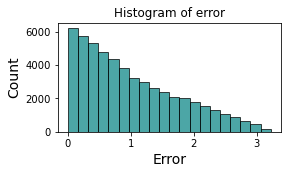

In [474]:
# get some more info on the point with high error in a_x, a_y, theta
# print(predictions[idx_max])
# print(targets[idx_max])
# print(theta_pred[idx_max])
# print(theta_true[idx_max])
# print(error_a_x[idx_max])
# print(error_a_y[idx_max])
# print(error_theta[idx_max])

# print(predictions[idx_min])
# print(targets[idx_min])
# print(theta_pred[idx_min])
# print(theta_true[idx_min])
# print(error_a_x[idx_min])
# print(error_a_y[idx_min])
# print(error_theta[idx_min])


Overall_error_norm = error_theta_norm #np.sqrt(error_a_x_norm**2 + error_a_y_norm**2 + error_theta_norm**2)
idx_max = np.argmax(Overall_error_norm)
idx_min = np.argmin(Overall_error_norm)

index_map   = evaluation['index_map']
frame_idx, node_idx = index_map[idx_max]
frame_idx_min, node_idx_min = index_map[idx_min]
print("Worst ax row:", idx_max, "came from frame", frame_idx, "node", node_idx)

print("Best ax row:", idx_min, "came from frame", frame_idx_min, "node", node_idx_min)
# histogram of Overall_error_norm
fig,ax = plt.subplots(1,1,figsize = (4,2))
ax.hist(Overall_error_norm,bins = 20,color = 'teal',edgecolor = 'black',alpha = 0.7)
ax.set_xlabel(r'Error',fontsize = 14)
ax.set_ylabel(r'Count',fontsize = 14)
ax.set_title(r'Histogram of error')
plt.show()

Worst ax row: 30319 came from frame 22 node 1850
Best ax row: 38641 came from frame 28 node 1269


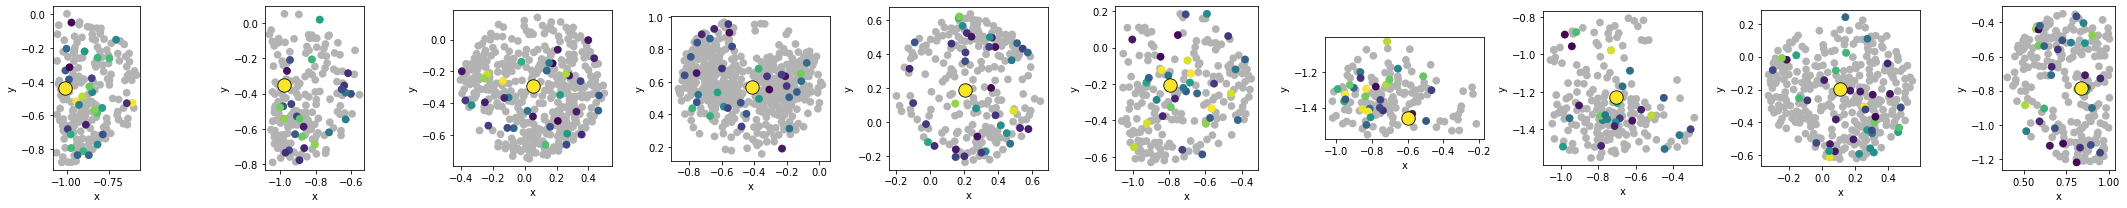

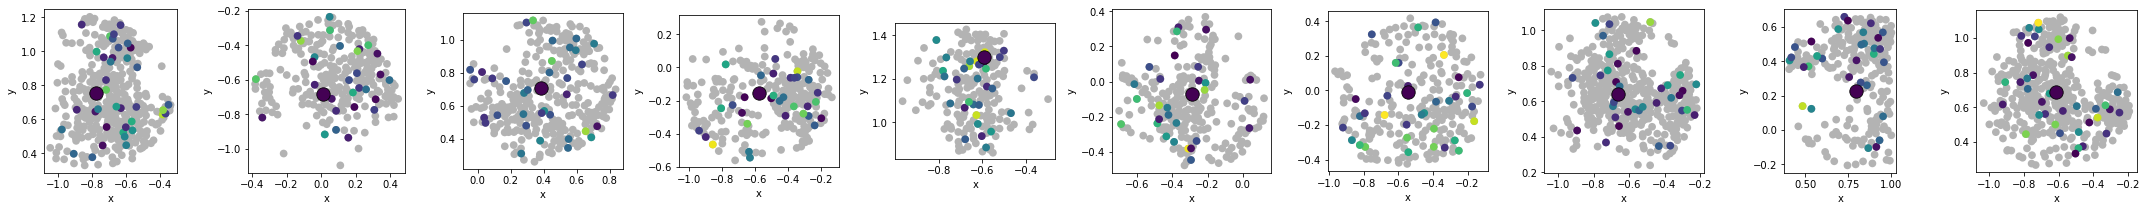

In [475]:
# Suppose you have per-node errors for this frame already:
# overall_err_frame is shape (num_nodes_in_frame,) with Overall_error_norm per node
# (or a dict; either is fine)

# Build dict of node->error for that frame from flattened arrays



index_map   = evaluation['index_map']

frame_idx_min, node_idx_min = index_map[idx_min]
print("Worst ax row:", idx_max, "came from frame", frame_idx, "node", node_idx)
print("Best ax row:", idx_min, "came from frame", frame_idx_min, "node", node_idx_min)

#get the IDs of the 10 worst nodes with maximum error
idx_worst = np.argsort(Overall_error_norm)[-10:]
fig,ax = plt.subplots(1,10,figsize = (30,3))
cc = 0
for ii in idx_worst:
    frame_idx, node_idx = index_map[ii]

    frame_idx_use = frame_idx
    neighbors_err_dict = {}
    for k, (f, n) in enumerate(index_map):
        if f == frame_idx_use:
            neighbors_err_dict[int(n)] = float(Overall_error_norm[k])

    err_center = neighbors_err_dict[node_idx]  # assuming you checked it's present/unmasked

    #err_center = float(overall_err_frame[node_idx])

    plot_2hop_center_only(
    train_data_[frame_idx],
    node_idx=node_idx,
    err_center=err_center,
    neighbors_err_dict=neighbors_err_dict,
    n_random_colored=40,
    show_colorbar=False,
    vmin=0,vmax=3,
    show_title=False,
    ax=ax[cc]
    )
    cc += 1
fig.tight_layout()


idx_best = np.argsort(Overall_error_norm)[:10]
fig,ax = plt.subplots(1,10,figsize = (30,3))
cc = 0
for ii in idx_best:
    frame_idx, node_idx = index_map[ii]

    frame_idx_use = frame_idx
    neighbors_err_dict = {}
    for k, (f, n) in enumerate(index_map):
        if f == frame_idx_use:
            neighbors_err_dict[int(n)] = float(Overall_error_norm[k])

    err_center = neighbors_err_dict[node_idx]  # assuming you checked it's present/unmasked

    #err_center = float(overall_err_frame[node_idx])

    plot_2hop_center_only(
    train_data_[frame_idx],
    node_idx=node_idx,
    err_center=err_center,
    neighbors_err_dict=neighbors_err_dict,
    n_random_colored=40,
    show_colorbar=False,
    vmin=0,vmax=3,
    show_title=False,
    ax=ax[cc]
    )
    cc += 1
fig.tight_layout()

In [447]:


err_center = Overall_error_norm[idx_max]     # <-- scalar error for the worst point
dp = train_data_[frame_idx]


#plot_2hop_center_only(dp, node_idx, err_center, show_colorbar=False)
plt.show()

frames_1509, err_1509 = node_error_over_frames(index_map, Overall_error_norm, node_id=1509)
print(np.argmin(np.abs(frames_1509-16)))
frame_id = np.argmin(np.abs(frames_1509-16))
print(err_1509[frame_id])

err_center = Overall_error_norm[idx_min]
dp = train_data_[frame_idx_min]
#plot_2hop_center_only(dp, node_idx_min, err_center, show_colorbar=False)
plt.show()

frames_2710, err_2710 = node_error_over_frames(index_map, Overall_error_norm, node_id=2710)
print(np.argmin(np.abs(frames_2710-7)))
frame_id = np.argmin(np.abs(frames_2710-7))
print(err_2710[frame_id])



7
0.73445654
0
0.46129763


In [448]:
from collections import defaultdict

node_to_frames = defaultdict(list)

for k, (frame_idx, node_idx) in enumerate(index_map):
    node_to_frames[int(node_idx)].append(frame_idx)

# sort for safety
for n in node_to_frames:
    node_to_frames[n].sort()

In [449]:
rows = []

R_density = 0.1  # choose a physical length scale (important!)
total_nodes = len(index_map)
#choose subset of index_map
index_map_subset = index_map[:500] 
total_nodes_subset = len(index_map_subset)
for k, (frame_idx, node_idx) in enumerate(index_map_subset):
    #print progress every 5%
    if k % (total_nodes_subset//5) == 0:
        print(f"{k}/{total_nodes_subset}")

    dp = train_data_[frame_idx]
    nodes = dp["nodes"]
    edges = dp["edges"]

    xy = nodes[:, :2]
    N = len(xy)

    adj = build_adjacency(edges, N)

    # ---------- error ----------
    err = Overall_error_norm[k]

    # ---------- neighbors ----------
    n1 = adj[node_idx]
    n_neighbors_1hop = len(n1)

    n2 = set()
    for u in n1:
        n2 |= adj[u]
    n2 -= n1
    n2.discard(node_idx)
    n_neighbors_2hop = len(n2)

    # ---------- local density (metric) ----------
    deltas = xy - xy[node_idx]
    dists = np.linalg.norm(deltas, axis=1)
    local_density = np.sum((dists < R_density) & (dists > 0))

    # ---------- lifetime ----------
    frames = node_to_frames[node_idx]
    frames_present_total = len(frames)
    frames_since_birth = frame_idx - frames[0]

    #make sure frames has no NaNs
    

    rows.append({
        "error": err,
        "frame": frame_idx,
        "node": node_idx,
        "n_neighbors_1hop": n_neighbors_1hop,
        "n_neighbors_2hop": n_neighbors_2hop,
        "local_density": local_density,
        "frames_present_total": frames_present_total,
        "frames_since_birth": frames_since_birth,
    })


0/500


KeyboardInterrupt: 

In [179]:
import pandas
df_errorCorr = pandas.DataFrame(rows)

print(df_errorCorr[["frame","node","frames_present_total","frames_since_birth"]].head())
print(df_errorCorr[["frame","node","frames_present_total","frames_since_birth"]].dtypes)

print("NaNs per column:")
print(df_errorCorr[["frames_present_total","frames_since_birth"]].isna().sum())

   frame  node  frames_present_total  frames_since_birth
0      0     1                    28                   0
1      0     2                    28                   0
2      0     3                    25                   0
3      0     4                    28                   0
4      0     5                    30                   0
frame                   int64
node                    int64
frames_present_total    int64
frames_since_birth      int64
dtype: object
NaNs per column:
frames_present_total    0
frames_since_birth      0
dtype: int64


In [180]:

corr_pearson  = df_errorCorr.corr(method="pearson")["error"].sort_values(ascending=False)
corr_spearman = df_errorCorr.corr(method="spearman")["error"].sort_values(ascending=False)
df_errorCorr[["frame", "frames_since_birth"]].describe()
print("Pearson:\n", corr_pearson)
print("\nSpearman:\n", corr_spearman)

print(df_errorCorr["frames_since_birth"].std())
print(df_errorCorr["frame"].std())



Pearson:
 error                   1.000000
local_density           0.041833
n_neighbors_1hop        0.036362
node                    0.019528
frames_present_total    0.000202
n_neighbors_2hop       -0.017983
frame                        NaN
frames_since_birth           NaN
Name: error, dtype: float64

Spearman:
 error                   1.000000
n_neighbors_1hop        0.074387
local_density           0.067173
frames_present_total    0.020957
node                    0.014207
n_neighbors_2hop       -0.024540
frame                        NaN
frames_since_birth           NaN
Name: error, dtype: float64
0.0
0.0


In [156]:
# first frame in this dataset
frame_idx = 0
node_idx = 0

frame_idx = index_map[0][0]
print(frame_idx)


0


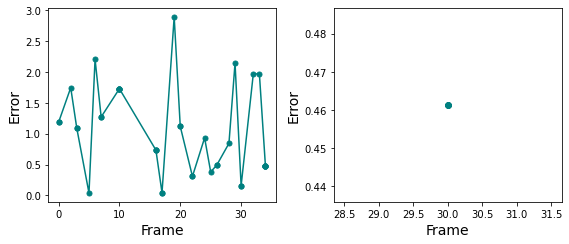

In [476]:
fig,ax = plt.subplots(1,2,figsize = (8,3.5))
# find the error in consecutive frames
errs_arr = []
frames_arr = []
for i in range(40):
    frame_id = np.argmin(np.abs(frames_1509-i))
    errs_arr.append(err_1509[frame_id])
    frames_arr.append(frames_1509[frame_id])
ax[0].plot(frames_arr,errs_arr,'o',color = 'teal',linestyle = '-',markersize = 5)
ax[0].set_xlabel('Frame',fontsize = 14)
ax[0].set_ylabel('Error',fontsize = 14)
#ax[0].set_title('Error in consecutive frames')

errs_arr = []
frames_arr = []
for i in range(40):
    frame_id = np.argmin(np.abs(frames_2710-i))
    errs_arr.append(err_2710[frame_id])
    frames_arr.append(frames_2710[frame_id])
ax[1].plot(frames_arr,errs_arr,'o',color = 'teal',linestyle = '-',markersize = 5)
ax[1].set_xlabel('Frame',fontsize = 14)
ax[1].set_ylabel('Error',fontsize = 14)
#ax[1].set_title('Error in consecutive frames')


fig.tight_layout()


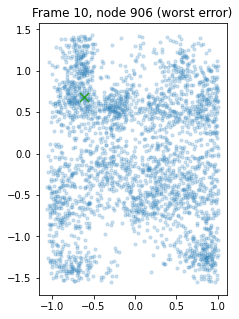

In [477]:
import numpy as np
import matplotlib.pyplot as plt

dp = train_data_[frame_idx]
nodes = dp['nodes']
edges = dp['edges']

xy = nodes[:, :2]
center = xy[node_idx]

# find neighbours via edges
mask_e = (edges[:,0] == node_idx) | (edges[:,1] == node_idx)
nbr_edges = edges[mask_e]
nbr_ids = np.unique(nbr_edges.flatten())
nbr_ids = nbr_ids[nbr_ids != node_idx]

fig, ax = plt.subplots(figsize=(5,5))

# plot all nodes faint
ax.scatter(xy[:,0], xy[:,1], s=10, alpha=0.2)

# plot neighbour nodes
ax.scatter(xy[nbr_ids,0], xy[nbr_ids,1], s=30)

# plot center node
ax.scatter(center[0], center[1], s=80, marker='x')

# draw edges connected to the node
for i, j in nbr_edges:
    ax.plot([xy[i,0], xy[j,0]], [xy[i,1], xy[j,1]], lw=1)

ax.set_aspect('equal', adjustable='box')
ax.set_title(f"Frame {frame_idx}, node {node_idx} (worst error)")
plt.show()


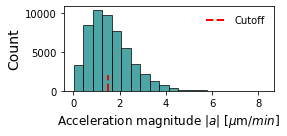

In [478]:
#make a histogram of a_mag
fig,ax = plt.subplots(1,1,figsize = (4,2))
ax.hist(a_mag,bins = 20,color = 'teal',edgecolor = 'black',alpha = 0.7)
ax.set_xlabel(r'Acceleration magnitude $|a|$ [$\mu$m$/min$]',fontsize = 12)
ax.set_ylabel(r'Count',fontsize = 14)
#ax.set_title(r'Histogram of $a$')
ax.plot([amin,amin],[0,2000],'r--',linewidth = 2,label = "Cutoff")
ax.legend(frameon = False)
fig.tight_layout()
#fig.savefig(datasave+'a_mag_histogram.png',dpi=1000)

In [479]:
print(theta_true_valid)
predictions[:, 0]

[-0.6659703   2.5881827  -2.040534   ... -2.8178422  -2.208425
 -0.87103355]


array([-0.00730954, -0.1250289 , -0.16137084, ...,  0.03028907,
       -0.04043727, -0.04124457], dtype=float32)

In [480]:
ax = predictions[:, 0]
ay = predictions[:, 1]
ax_valid = ax[valid]
ay_valid = ay[valid]
sx = Overall_noise['per_dim_std'][0]
sy = Overall_noise['per_dim_std'][1]

sigma_a = np.sqrt(sx**2 + sy**2)

a_mag = np.sqrt(ax_valid**2 + ay_valid**2)

c = 5.0  # try 3, 5, 10
#valid = a_mag > c * sigma_a

den = ax_valid**2 + ay_valid**2
var_theta = (ay_valid**2 * sx**2 + ax_valid**2 * sy**2) / (den**2)

sigma_theta_global = np.sqrt(np.mean(var_theta))

print("kept fraction:", np.mean(valid))
print("Global sigma_theta (rad):", sigma_theta_global)
print("Global sigma_theta (deg):", np.degrees(sigma_theta_global))



kept fraction: 0.31400433547615486
Global sigma_theta (rad): 24.757162
Global sigma_theta (deg): 1418.4808


In [481]:
dtheta = (theta_true_valid - theta_pred_valid + np.pi) % (2*np.pi) - np.pi  # wrap to [-pi,pi]
print(dtheta)
overall_theta_rms = np.sqrt(np.mean(dtheta*dtheta))
print("overall_theta_rms",overall_theta_rms)


[ 1.5370052  -1.0206978  -0.08141541 ... -2.0393353  -0.22608066
 -1.1918337 ]
overall_theta_rms 1.7019117


In [482]:
targets_valid = targets #[valid]
ax = targets_valid[:,0]   # or predictions[:,0]
ay = targets_valid[:,1]   # or predictions[:,1]

sigma_x = Overall_noise['per_dim_std'][0]
sigma_y = Overall_noise['per_dim_std'][1]

den = ax**2 + ay**2
m = np.sqrt(den)

# mask out tiny magnitudes where direction is meaningless
m_min = 5.0 * np.sqrt(sigma_x**2 + sigma_y**2)   # simple SNR threshold
valid = m > m_min

theta = np.arctan2(ay, ax)

var_theta = (ay**2 * sigma_x**2 + ax**2 * sigma_y**2) / (den**2)
sigma_theta = np.sqrt(var_theta)

print(np.mean(sigma_theta))


1.344051


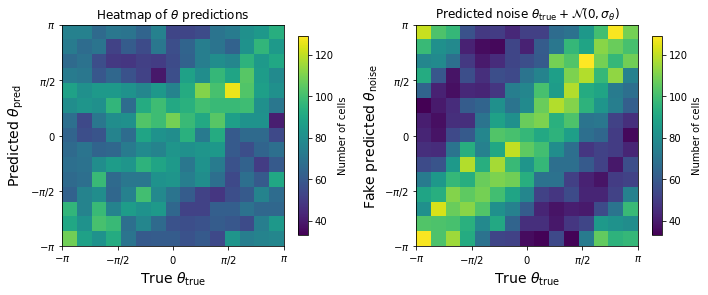

In [483]:
fig2,ax2 = plt.subplots(1,2,figsize = (10,4))

# calculate angular noise

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
#make some fake theta_pred from theta_true + gaussian noise. Noise taken from our estimate of the noise
theta_pred_fake = np.zeros(len(theta_true_valid))
for i in range(len(theta_true_valid)):
    theta_pred_fake[i] = theta_true_valid[i] + np.random.normal(0,overall_theta_rms) #theta_true[i] + 
    if theta_pred_fake[i] > np.pi:
        theta_pred_fake[i] = theta_pred_fake[i] - 2*np.pi
    elif theta_pred_fake[i] < -np.pi:
        theta_pred_fake[i] = theta_pred_fake[i] + 2*np.pi
heatmap_fake, xedges_fake, yedges_fake = np.histogram2d(theta_true_valid, theta_pred_fake, bins=20)
# 1) Use the SAME bin edges for both plots (critical)
bins = 15
# xmin, xmax = np.min(theta_true), np.max(theta_true)
# print(xmin, xmax)

# ymin = min(np.min(theta_pred), np.min(theta_pred_fake))
# ymax = max(np.max(theta_pred), np.max(theta_pred_fake))
# print(ymin, ymax)

xedges = np.linspace(-np.pi, np.pi, bins + 1)
yedges = np.linspace(-np.pi, np.pi, bins + 1)

heatmap, _, _      = np.histogram2d(theta_true_valid, theta_pred_valid,      bins=[xedges, yedges])
heatmap_fake, _, _ = np.histogram2d(theta_true_valid, theta_pred_fake, bins=[xedges, yedges])
heat_min = np.min(heatmap_fake)
heat_max = np.max(heatmap_fake)
# 2) Plot with identical extent + identical aspect
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im0 = ax2[0].imshow(heatmap.T, extent=extent, origin="lower",
                    cmap="viridis", aspect="equal",vmin = heat_min,vmax = heat_max)
im1 = ax2[1].imshow(heatmap_fake.T, extent=extent, origin="lower",
                    cmap="viridis", aspect="equal",vmin = heat_min,vmax = heat_max)

# 3) Force identical axis limits (belt + braces)
for ax in ax2:
    ax.set_xlim(xedges[0], xedges[-1])
    ax.set_ylim(yedges[0], yedges[-1])

# 4) One colorbar for both axes so layout stays aligned
cbar = fig2.colorbar(im0, ax=ax2[0], shrink=0.9)
cbar.set_label("Number of cells")
cbar = fig2.colorbar(im1, ax=ax2[1], shrink=0.9)
cbar.set_label("Number of cells")

# Labels/titles
ax2[0].set_xlabel(r"True $\theta_{\mathrm{{true}}}$", fontsize=14)
ax2[0].set_ylabel(r"Predicted $\theta_{\mathrm{{pred}}}$", fontsize=14)
ax2[0].set_title(r"Heatmap of $\theta$ predictions")

ax2[1].set_xlabel(r"True $\theta_{\mathrm{{true}}}$", fontsize=14)
ax2[1].set_ylabel(r"Fake predicted $\theta_{\mathrm{{noise}}}$", fontsize=14)
ax2[1].set_title(r"Predicted noise $\theta_{\mathrm{{true}}}+\mathcal{N}(0,\sigma_{\theta})$")
ax2[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])

fig2.tight_layout()
#fig2.savefig(datasave+'theta_heatmap.png',dpi=1000)


In [843]:
# name ="Version_i_UD_AllData"
# #name = "Version_i_OD_AllData_50_EMT"
# loaded_model = load_model(datasave+name+'.h5', 
#                          hidden_dim=64, 
#                          gamma_init=0.01, 
#                          save_format='weights')
# loaded_model_history = load_history(datasave+name+'_history.json')

# name2 ="Version_i_UD_PrevData_Attr_range70_49"
# name2 ="Version_i_UD_PrevData_Attr_range100_NoFenv_49"
name2 ="Version_iii_UD_AllData"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model7 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history7 = load_history(datasave+name+'_history.json')

# name2 ="Version_i_UD_AllData_50_Last50_EMT"
# #name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
# loaded_model3 = load_model(datasave+name2+'.h5', 
#                          hidden_dim=64, 
#                          gamma_init=0.01, 
#                          save_format='weights')
# loaded_model_history3 = load_history(datasave+name+'_history.json')


name ="Version_i_UD_AllData"
#name = "Version_i_OD_AllData_50_EMT"
loaded_model = load_model(datasave+name+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_PrevData_Attr_range70_49"
name2 ="Version_i_UD_PrevData_Attr_range100_NoFenv_49"
name2 ="Version_i_UD_AllData_50_First75_EMT"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model2 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history2 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_First50_EMT"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model3 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history3 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_First25_EMT"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model4 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history4 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_Last50_EMT"
loaded_model5 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history5 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_Last25_EMT"
loaded_model6 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history6 = load_history(datasave+name+'_history.json')



# name = "Version_i_OD_AllData_50_EMT"
# loaded_model = load_model(datasave+name+'.h5', 
#                          hidden_dim=64, 
#                          save_format='weights')
# loaded_model_history = load_history(datasave+name+'_history.json')


# name2 = "Version_i_OD_Attr_range50_49"
# #name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
# loaded_model2 = load_model(datasave+name2+'.h5', 
#                          hidden_dim=64, 
#                          save_format='weights')
# loaded_model_history2 = load_history(datasave+name+'_history.json')



ForceGNN model created with hidden_dim=64, gamma_init=0.01
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: -0.039420
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_history.json
  Number of epochs: 60
  Final train loss: 665.299622
  Final val loss: 658.258667
ForceGNN model created with hidden_dim=64, gamma_init=0.01
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_50_First75_EMT.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: -0.044646
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_history.json
  Number of epochs: 60
  Final train loss: 665.299622


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_50_Last75_EMT.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [844]:
name2 ="Version_iii_UD_AllData"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model7 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history7 = load_history(datasave+name+'_history.json')

ForceGNN model created with hidden_dim=64, gamma_init=0.01
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_iii_UD_AllData.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: 0.026010
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_history.json
  Number of epochs: 60
  Final train loss: 665.299622
  Final val loss: 658.258667


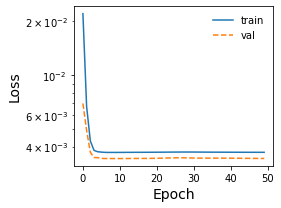

In [81]:
# Plot training history
fig,ax  = plt.subplots(figsize = (4,3))
#history2 = loaded_model_history

ax.plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train')
ax.plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val')
#ax.plot(history2['train_loss'],color = 'black',linestyle = ':',label = 'train')#
#ax.plot(history2['val_loss'],color = 'black',linestyle = ':',label = 'val')
ax.legend(frameon = False)
ax.set_yscale('log')
ax.set_xlabel('Epoch',fontsize = 14)
ax.set_ylabel('Loss',fontsize = 14)
fig.tight_layout()


In [82]:
# noise_stats = estimate_noise_magnitude(model, test_data)
# #print(f"Per-dimension std: {noise_stats['per_dim_std']}")
# print(f"Overall RMS: {noise_stats['overall_rms']}")
# print(f"Number of samples: {noise_stats['num_samples']}")
# print(f"Mean residual: {noise_stats['mean_residual']}")  # Should be ~0 if unbiased
#Gamma = -get_gamma(model)
Gamma2 = -get_gamma(model)
#Gamma3 = -get_gamma(loaded_model2)
#print(f"Gamma: {Gamma}")
print(f"Gamma2: {Gamma2}")
#print(f"Gamma3: {Gamma3}")
#print(f"Gamma2: {Gamma2}")
# #GammaTrue = 1/(damp*frame)
# #print(f"Real Noise: {MagnutudeNoise} should equal overall_rms {noise_stats['overall_rms']}")
# fig,ax=plt.subplots(1,2,figsize=(8,3))
# ax[0].plot([0,1],[noise_stats['overall_rms'],noise_stats['overall_rms']],color = clrs[0],marker = 'o',linestyle = '')
# ax[0].set_xticks([0,1])
# ax[0].set_xticklabels(['Real Noise','Model Noise'])
# ax[1].plot([0,1],[Gamma,Gamma],color = clrs[1],marker = 'o',linestyle = '')
# ax[1].set_xticks([0,1])
# ax[1].set_xticklabels(['True Gamma','Model Gamma'])
# ax[1].set_ylabel('Noise Magnitude')
# fig.tight_layout()

Gamma2: 0.03424461930990219


In [677]:
def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return dEdr

def force_environment(x,y,kappa_x,kappa_y,x_0,y_0):
    r_vec = np.array([x-x_0,y-y_0])
    r = np.linalg.norm(r_vec)
    Fx = -kappa_x*(x-x_0)
    Fy = -kappa_y*(y-y_0)
    return np.array([Fx,Fy])
    

In [43]:
# Get force at a specific distance
sigma = 1.5
l_da = 0.1
rcut = sigma*2
epsilon = 0.5
r_arr = np.linspace(0.30,50/max_dist)
force_infer = []
force_infer2 = []
force_infer3 = []
force_infer4 = []
force_true = []
for r in r_arr:
    #force_infer.append(get_force_at_distance(loaded_model3, r))
    #force_infer2.append(get_force_at_distance(loaded_model, r))
    #force_infer3.append(get_force_at_distance(loaded_model2, r))
    force_infer4.append(get_force_at_distance(model, r))
    #force_true.append(soft_lj_force(r, epsilon, sigma, rcut, l_da))
    #print(f"Force at distance r={r}: {force:.6f}")


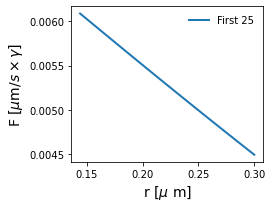

In [44]:

r_arr_plot = np.multiply(r_arr,max_dist)
fig,ax  = plt.subplots(figsize = (4,3))
scaleF = 1
ax.plot(r_arr,np.multiply(force_infer4,scaleF),color = clrs[0],linestyle = '-',linewidth = 2,label = 'First 25')
#
#ax.plot(r_arr,np.multiply(force_infer,scaleF),color = clrs[2],linestyle = '-',linewidth = 2,label = 'First 50')
#ax.plot(r_arr,np.multiply(force_infer3,scaleF),color = 'tab:pink',linestyle = '-',linewidth = 2,label = 'First 75')
#ax.plot(r_arr,np.multiply(force_infer2,scaleF),color = 'tab:purple',linestyle = '-',linewidth = 2,label = 'All data')

#ax.plot(r_arr,list(force_true),color = 'black',linestyle = ':',label = 'actual')
ax.set_xlabel(r'r [$\mu$ m]',fontsize = 14)
ax.set_ylabel(r'F [$\mu$m$/s \times \gamma$]',fontsize = 14)
#ax.set_ylim([-0.2,1.5])
#ax.plot([0,50],[0,0],'k--')
ax.legend(frameon = False)
#ax.set_ylim([-0.5,2.4])
fig.tight_layout()

# # Query multiple distances
# distances = [0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
# for r in distances:
#     force = get_force_at_distance(model, r)
#     print(f"r={r:.1f}: F_r={force:.6f}")


In [ ]:
# Evaluate on test data
data_trains = train_data_rolling #[train_data_0,train_data_1,train_data_2,train_data_3,train_data_4,train_data_5]
r_squares = []
r_squares_ax = []
r_squares_ay = []
#for i in range(len(trains)):
evaluation = evaluate_model(loaded_model,train_data,verbose = False)
#print("Evaluating ",i,"out of ",len(data_trains))

# Plot predictions vs actual
#plot_predictions(evaluation)
predictions = evaluation['predictions']
targets = evaluation['targets']
# fig,ax = plt.subplots(1,2,figsize = (8,3))
# ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = clrs[2],linestyle = '',markersize = 2)
# ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
# ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = clrs[2],linestyle = '',markersize = 2)
# ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
# ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
# ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
# ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
# ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
# ax[0].legend(frameon = False)
# fig.tight_layout()

# calculate R^2 (on test data)
# R^2 = 1 - (sum((y_true - y_pred)**2)) / (sum((y_true - y_mean)**2))
# R^2 = 1- evaluation['mse']/\sum(targets-np.mean(targets))**2
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)

print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")
#ax[0].set_ylim([-1,1])
r_squares.append((rsq_ax+rsq_ay)/2)
r_squares_ax.append(rsq_ax)
r_squares_ay.append(rsq_ay)


R^2 for ax: 0.0017
R^2 for ay: 0.0018
Average R^2: 0.0017


In [153]:
print(r_squares)
print(r_squares_ax)
print(r_squares_ay)
print("var ax:", np.var(targets[:,0]), "var ay:", np.var(targets[:,1]))
print("std ax:", np.std(targets[:,0]), "std ay:", np.std(targets[:,1]))


[0.0005799233913421631, -0.006135702133178711, -0.0064792633056640625, -0.005572915077209473, -7.787346839904785e-05, 0.0023116767406463623, 0.000951617956161499, 0.0002193450927734375, -1.9341707229614258e-05, 0.0005606412887573242, -0.0015418529510498047, -0.0001849532127380371, 0.001377195119857788, 0.0011031925678253174, 0.0006569921970367432, 0.0007000565528869629, 0.000549614429473877, 1.2189149856567383e-05, -0.0006220340728759766, -0.0010631084442138672, 0.0019764304161071777, 0.0024518072605133057, 0.003076612949371338, 0.002116560935974121, 0.0019738972187042236, -0.00029718875885009766, 0.0007128119468688965, 0.000457763671875, 0.0007289350032806396, 0.0008140504360198975, 0.0002789497375488281, -0.001381605863571167, 0.0009543895721435547, 0.00188446044921875, 0.0014324188232421875, 0.0012323558330535889, 0.0011709034442901611, 0.00014865398406982422, -0.000991910696029663, -0.0012792348861694336, -0.0018449127674102783, -0.0018864870071411133, -0.00587087869644165, -0.0012

In [46]:
# Plot force components for a test frame
kappa_x = 0.4
kappa_y = 0.2
#get x and y from the min and max of the data
x_min = data_clean['x'].min()
x_max = data_clean['x'].max()
y_min = data_clean['y'].min()
y_max = data_clean['y'].max()
print(x_min,x_max,y_min,y_max)
x_arr = np.linspace(x_min,x_max,40)
y_arr = np.linspace(y_min,y_max,40)
x_arr_real = np.linspace(x_min*max_dist*0.9,x_max*max_dist*0.9,40)
y_arr_real = np.linspace(y_min*max_dist*0.9,y_max*max_dist*0.9,40)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = get_force_environment(model, x, y)
        #F_env_true[i,j,:] = force_environment(x,y,kappa_x,kappa_y,0,0)

# Plot force components for a test frame

-0.8547702727015694 0.82578656275203 -0.9 0.7766435018030129


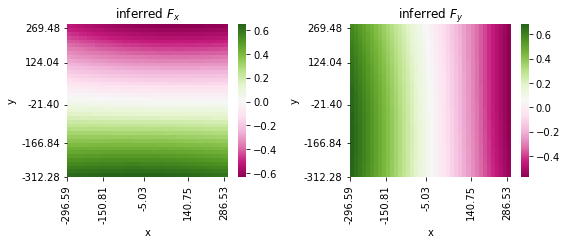

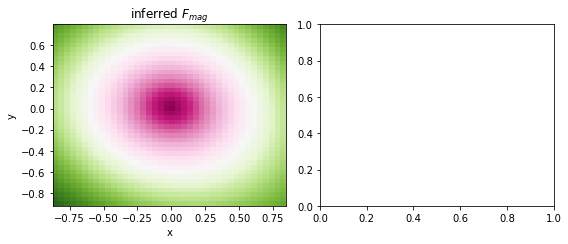

In [48]:
fig,ax = plt.subplots(1,2,figsize = (8,3.5))
fig2,ax2 = plt.subplots(1,2,figsize = (8,3.5))
x_ticks_plot = np.linspace(x_min*max_dist,x_max*max_dist,5)
y_ticks_plot = np.linspace(y_min*max_dist,y_max*max_dist,5)
x_tick_indices = [np.argmin(np.abs(x_arr_real - val)) for val in x_ticks_plot]
y_tick_indices = [np.argmin(np.abs(y_arr_real - val)) for val in y_ticks_plot]

# Create heatmaps
#vmin = -3
#vmax = 3
sns.heatmap(F_env_infer[:,:,0], ax=ax[0], cmap='PiYG',
            xticklabels=[f'{x:.2f}' for x in x_ticks_plot],
            yticklabels=[f'{y:.2f}' for y in y_ticks_plot])

sns.heatmap(F_env_infer[:,:,1], ax=ax[1], cmap='PiYG',
            xticklabels=[f'{x:.2f}' for x in x_ticks_plot],
            yticklabels=[f'{y:.2f}' for y in y_ticks_plot])

# Set tick positions
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks_plot])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks_plot])


ax[0].invert_yaxis()
ax[1].invert_yaxis()
##ax[0].set_xticks(ax[0].get_xticks()[::4])
#ax[1].set_xticks(ax[1].get_xticks()[::4])
ax[0].set_title(r'inferred $F_x$')
ax[1].set_title(r'inferred $F_y$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()

# plot force magnitude
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')
ax2[0].pcolormesh(X, Y, F_mag, shading='auto', cmap='PiYG')
ax2[0].set_title(r'inferred $F_{mag}$')
ax2[0].set_xlabel('x')
ax2[0].set_ylabel('y')
fig2.tight_layout()



# fig,ax = plt.subplots(1,2,figsize = (8,3))
# sns.heatmap(F_env_infer[:,:,1],ax=ax[0], cmap='viridis')
# sns.heatmap(F_env_true[:,:,1],ax=ax[1], cmap='viridis')
# ax[0].set_title(r'inferred $F_y$')
# ax[1].set_title(r'actual $F_y$')
# ax[0].set_xlabel('x')
# ax[0].set_ylabel('y')
# ax[1].set_xlabel('x')
# ax[1].set_ylabel('y')
# fig.tight_layout()


In [101]:

def node_error_over_frames(index_map, overall_error, node_id):
    """
    Returns two arrays (frames, errors) for all occurrences of node_id
    in the flattened masked arrays.
    """
    index_map_arr = np.asarray(index_map, dtype=int)  # shape (M, 2)
    frames = index_map_arr[:, 0]
    nodes  = index_map_arr[:, 1]

    sel = (nodes == int(node_id))
    frames_sel = frames[sel]
    errors_sel = np.asarray(overall_error)[sel]

    # sort by frame index (just in case)
    order = np.argsort(frames_sel)
    return frames_sel[order], errors_sel[order]


In [142]:
def get_edge_pairs(edges):
    edges = np.asarray(edges)
    if edges.ndim == 2 and edges.shape[0] == 2:      # (2, E)
        return edges.T.astype(int)
    if edges.ndim == 2 and edges.shape[1] >= 2:      # (E, 2+)
        return edges[:, :2].astype(int)
    raise ValueError(f"Unrecognized edges shape {edges.shape}")

def plot_2hop_center_only(
    data_point,
    node_idx,
    err_center,
    neighbors_err_dict=None,
    n_random_colored=0,
    hop=2,
    cmap="viridis",
    vmin=0.0,
    vmax=5.0,
    show_colorbar=True,
    ax=None,
    seed=None,
    neighbor_size=60,
    center_size=180,
    show_title=True,
):
    """
    Plot ONLY node_idx and its 1-hop and 2-hop neighbors on a given axis.

    - neighbors grey
    - center colored by err_center
    - randomly choose n_random_colored neighbors to color by error
    - fixed color scale [vmin, vmax]
    - no lines
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    nodes = data_point["nodes"]
    edges = data_point["edges"]
    xy = nodes[:, :2]
    N = xy.shape[0]
    node_idx = int(node_idx)

    # --- edges ---
    edge_pairs = get_edge_pairs(edges)

    # --- adjacency ---
    adj = [set() for _ in range(N)]
    for i, j in edge_pairs:
        i = int(i); j = int(j)
        adj[i].add(j)
        adj[j].add(i)

    # --- BFS to hop ---
    frontier = {node_idx}
    visited = {node_idx}
    layers = [set([node_idx])]

    for _ in range(hop):
        nxt = set()
        for u in frontier:
            nxt |= adj[u]
        nxt -= visited
        layers.append(nxt)
        visited |= nxt
        frontier = nxt

    first  = layers[1] if len(layers) > 1 else set()
    second = layers[2] if len(layers) > 2 else set()
    neighbor_nodes = sorted(list(first | second))

    # --- random neighbors to color ---
    rng = np.random.default_rng(seed)
    n_pick = min(int(n_random_colored), len(neighbor_nodes))
    picked = rng.choice(neighbor_nodes, size=n_pick, replace=False).tolist() if n_pick > 0 else []

    neighbors_err_dict = neighbors_err_dict or {}
    picked_with_err = [n for n in picked if n in neighbors_err_dict]

    # --- plot ---
    if neighbor_nodes:
        ax.scatter(
            xy[neighbor_nodes, 0], xy[neighbor_nodes, 1],
            s=neighbor_size, color="0.7", edgecolors="none"
        )

    if picked_with_err:
        vals = [neighbors_err_dict[n] for n in picked_with_err]
        ax.scatter(
            xy[picked_with_err, 0], xy[picked_with_err, 1],
            c=vals, s=neighbor_size,
            cmap=cmap, vmin=vmin, vmax=vmax,
            edgecolors="none"
        )

    sc_center = ax.scatter(
        [xy[node_idx, 0]], [xy[node_idx, 1]],
        c=[err_center], s=center_size,
        cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolors="k", linewidths=0.8
    )

    if show_colorbar:
        cbar = fig.colorbar(sc_center, ax=ax)
        cbar.set_label("Overall_error_norm")

    ax.set_aspect("equal", adjustable="box")
    if show_title:
        ax.set_title(
            f"node {node_idx} | err={err_center:.3g} | "
            f"colored {len(picked_with_err)}/{n_pick}"
        )
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # --- zoom ---
    local_nodes = [node_idx] + neighbor_nodes
    xs = xy[local_nodes, 0]
    ys = xy[local_nodes, 1]
    pad_x = 0.05 * (xs.max() - xs.min() + 1e-9)
    pad_y = 0.05 * (ys.max() - ys.min() + 1e-9)
    ax.set_xlim(xs.min() - pad_x, xs.max() + pad_x)
    ax.set_ylim(ys.min() - pad_y, ys.max() + pad_y)

    return ax


In [157]:
def build_adjacency(edges, N):
    edge_pairs = get_edge_pairs(edges)
    adj = [set() for _ in range(N)]
    for i, j in edge_pairs:
        adj[i].add(j)
        adj[j].add(i)
    return adj


